# 🔬 Public Opinion on Single Parenthood in DACH Reddit Communities (2015–2023)

**Proof-of-Concept Research Tool**

This notebook analyses public discourse about *Alleinerziehende* (single parents) across German-speaking Reddit communities in the DACH region (Germany, Austria, Switzerland). It collects posts from 2015–2023, applies multilingual sentiment analysis, and produces statistical summaries and visualisations suitable for social-science research.

**Key design choices:**
- **No paid APIs** — uses only free, open-source tools
- **No Reddit credentials** — data comes from the Arctic Shift public archive
- **Offline-capable** — after the first run (which downloads one ~1 GB model), everything runs locally
- **Caching** — raw data and sentiment results are cached to JSON so you never re-fetch unnecessarily

## Cell 1 — Install Dependencies

In [1]:
# Cell 1 — Install all required packages (runs once; safe to re-run)
# This cell installs everything needed. On Google Colab, all installs
# happen in your temporary runtime and won't affect your system.

!pip install -q \
    requests \
    pandas \
    matplotlib \
    seaborn \
    "vaderSentiment" \
    "transformers>=4.36.0" \
    "torch>=2.0" \
    "safetensors>=0.4" \
    "protobuf>=3.20" \
    "scikit-learn>=1.0" \
    langdetect \
    scipy \
    nltk

# Topic modeling stack — BERTopic uses a sentence-transformer (~400 MB
# multilingual model on first run) for much better topic quality than
# bag-of-words approaches like LDA/NMF.
!pip install -q \
    "bertopic>=0.15" \
    "sentence-transformers>=2.2" \
    "umap-learn>=0.5" \
    "hdbscan>=0.8"

print("✅ All packages installed successfully.")

✅ All packages installed successfully.


## Cell 2 — Import Libraries

In [2]:
# Cell 2 — Import all libraries used throughout the notebook

import os
import json
import time
import re
import html
import warnings
from datetime import datetime, timezone
from collections import Counter, defaultdict

import requests
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    pipeline,
)
from langdetect import detect, LangDetectException
import nltk

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# Download NLTK stopwords for text statistics
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

# Suppress noisy warnings that don't affect results
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Plotting defaults
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

print("✅ All imports ready.")

/Users/maksimsmirnov/Desktop/thesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/maksimsmirnov/Desktop/thesis/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All imports ready.


## Cell 3 — Configuration

Edit the lists below if you want to adjust the scope of the analysis  
(e.g., add subreddits, change the time window, or add keywords).

In [3]:
# Cell 3 — Central configuration — edit here to customise the analysis

# Subreddits to search (DACH-focused, expanded)
SUBREDDITS = [
    "Austria", "de", "Switzerland", "wien", "DACH",
    "germany", "Oesterreich", "Schweiz", "berlin", "hamburg",
    "Munich", "cologne", "Frankfurt", "Stuttgart", "Düsseldorf",
    "AskEurope", "europe", "beziehungen", "eltern", "fragreddit", 
    "fragtmaenner", "fragnefrau", "finanzen", "ratschlag"
]

# German keywords
KEYWORDS_DE = [
    "Alleinerziehende",
    "Alleinerziehender",
    "Einelternfamilie",
    "alleinerziehend",
    "Alleinerziehenden",
    "Alleinerzieherin",
    "Sozialmutter",
    "Solovater",
    "Solomutter",
]

# English keywords
KEYWORDS_EN = [
    "single parent",
    "single mother",
    "single father",
    "single mom",
    "single dad",
    "lone parent",
]

KEYWORDS = KEYWORDS_DE + KEYWORDS_EN

# Year range (inclusive)
YEAR_START = 2015
YEAR_END = 2023
YEARS = list(range(YEAR_START, YEAR_END + 1))

# API settings
ARCTIC_SHIFT_URL          = "https://arctic-shift.photon-reddit.com/api/posts/search"
ARCTIC_SHIFT_COMMENTS_URL = "https://arctic-shift.photon-reddit.com/api/comments/search"
PULLPUSH_URL              = "https://api.pullpush.io/reddit/search/submission/"
PULLPUSH_COMMENTS_URL     = "https://api.pullpush.io/reddit/search/comment/"
REQUEST_DELAY     = 0.3   # seconds between API calls
PAGE_LIMIT        = 100   # posts per page (Arctic Shift max is 100)
MAX_PAGES         = 20    # safety cap per combo (= up to 2 000 posts per combo)
MAX_COMMENTS_PER_POST = 500  # max comments to fetch per post

# Cache file paths
RAW_CACHE_FILE       = "raw_posts_cache.json"
COMMENTS_CACHE_FILE  = "raw_comments_cache.json"
SENTIMENT_CACHE_FILE = "sentiment_cache.json"

# RoBERTa batch size (lower if you run out of memory)
ROBERTA_BATCH_SIZE = 16

# ── Topic analysis settings ───────────────────────────────────────────────────
# Embedding model: multilingual, ~400 MB download on first run.
# "paraphrase-multilingual-MiniLM-L12-v2" handles German + English natively.
EMBEDDING_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"

# BERTopic will auto-detect the number of topics via HDBSCAN clustering.
# Set MIN_TOPIC_SIZE to control granularity: lower = more topics.
MIN_TOPIC_SIZE = 20   # minimum posts per topic cluster

# Cache for topic results
TOPIC_CACHE_FILE = "topic_cache.json" 
# ── Relevance filtering ──────────────────────────────────────────────────────
# After collection, posts are hard-filtered against these keywords.
# German keywords use SUBSTRING matching (to catch compound words like
# "Alleinerziehendenhilfe"). English keywords use WORD-BOUNDARY matching
# with support for plurals (mothers/fathers) and hyphens (single-parent).

RELEVANCE_KEYWORDS_DE = [
    "alleinerziehende", "alleinerziehender", "alleinerziehenden",
    "alleinerziehend", "einelternfamilie", "einelternhaushalt",
    "allein erziehend",
    "sorgerecht", "kindesunterhalt", "unterhaltspflicht",
    "unterhaltsvorschuss",
]

RELEVANCE_KEYWORDS_EN = [
    "single parent", "single mother", "single father",
    "single parenting", "single mom", "single dad",
    "solo parent", "lone parent",
]

def build_query(keyword):
    """Wrap multi-word keywords in quotes for exact phrase matching at API level."""
    if " " in keyword.strip():
        return f'"{keyword}"'
    return keyword

print("✅ Configuration loaded.")
print(f"   {len(SUBREDDITS)} subreddits × {len(KEYWORDS)} keywords × {len(YEARS)} years")
print(f"   = up to {len(SUBREDDITS) * len(KEYWORDS) * len(YEARS)} query-combos")
print(f"   = up to {len(SUBREDDITS) * len(KEYWORDS) * len(YEARS) * PAGE_LIMIT * MAX_PAGES:,} posts (with pagination)")


✅ Configuration loaded.
   5 subreddits × 15 keywords × 9 years
   = up to 675 query-combos
   = up to 1,350,000 posts (with pagination)


## Cell 4 — Data Collection

This cell fetches posts from the **Arctic Shift** public Reddit archive  
(with PullPush as a fallback). Results are cached to `raw_posts_cache.json`  
so you only need internet access the first time.

In [4]:
# Cell 4 — Fetch Reddit posts via Arctic Shift / PullPush (with caching + pagination)

def fetch_page_arctic_shift(keyword, subreddit, after_ts, before_ts):
    """
    Fetch one page from Arctic Shift.
    Returns (posts_list, last_result_ts) where last_result_ts is the
    oldest timestamp in the page (used as the next `before` cursor).
    """
    q = build_query(keyword)
    params = {
        "query":     q,             # multi-word keywords are quoted
        "subreddit": subreddit,
        "after":     int(after_ts),
        "before":    int(before_ts),
        "limit":     PAGE_LIMIT,
        "sort":      "desc",
    }
    try:
        resp = requests.get(ARCTIC_SHIFT_URL, params=params, timeout=30)
        if resp.status_code == 200:
            body  = resp.json()
            posts = body.get("data") or []
            # Arctic Shift returns meta.last_result as the oldest timestamp
            last_ts = (body.get("meta") or {}).get("last_result")
            return posts, last_ts
    except Exception:
        pass
    return [], None


def fetch_page_pullpush(keyword, subreddit, after_ts, before_ts):
    """PullPush fallback — used only when Arctic Shift fails completely."""
    try:
        q = build_query(keyword)
        params = {
            "q":         q,
            "subreddit": subreddit,
            "after":     int(after_ts),
            "before":    int(before_ts),
            "size":      PAGE_LIMIT,
            "sort":      "desc",
        }
        resp = requests.get(PULLPUSH_URL, params=params, timeout=30)
        if resp.status_code == 200:
            data  = resp.json()
            posts = data.get("data") or []
            if posts:
                last_ts = min(int(p.get("created_utc", before_ts)) for p in posts)
                return posts, last_ts
    except Exception:
        pass
    return [], None


def fetch_all_pages(keyword, subreddit, after_ts, before_ts):
    """
    Paginate through ALL posts for one (keyword, subreddit, year) combo.

    Uses Arctic Shift's meta.last_result as the cursor: each response
    contains the oldest timestamp in that page, which becomes the next
    `before` so we walk backwards through the year.
    Falls back to PullPush only if Arctic Shift returns nothing at all
    on the very first page.
    """
    collected = []
    seen_ids  = set()
    current_before = int(before_ts)
    used_pullpush  = False

    for _page in range(MAX_PAGES):
        posts, last_ts = fetch_page_arctic_shift(
            keyword, subreddit, int(after_ts), current_before
        )
        time.sleep(REQUEST_DELAY)

        # If Arctic Shift gave nothing on page 1, try PullPush once
        if not posts and _page == 0 and not used_pullpush:
            posts, last_ts = fetch_page_pullpush(
                keyword, subreddit, int(after_ts), current_before
            )
            used_pullpush = True
            time.sleep(REQUEST_DELAY)

        if not posts:
            break

        new_posts = [p for p in posts if p.get("id") not in seen_ids]
        if not new_posts:
            break

        for p in new_posts:
            seen_ids.add(p.get("id"))
        collected.extend(new_posts)

        # Stop if we got a partial page — no more results
        if len(posts) < PAGE_LIMIT:
            break

        # Advance cursor using Arctic Shift's meta cursor, or manual fallback
        if last_ts is not None:
            next_before = int(last_ts) - 1
        else:
            next_before = min(int(p.get("created_utc", current_before)) for p in new_posts) - 1

        if next_before <= int(after_ts):
            break
        current_before = next_before

    return collected


def collect_all_posts():
    """Loop over every year × keyword × subreddit combination with pagination."""
    all_posts = []
    seen_ids  = set()
    total_combos = len(YEARS) * len(KEYWORDS) * len(SUBREDDITS)
    done = 0

    for year in YEARS:
        after_ts  = int(datetime(year,  1,  1,  0,  0,  0, tzinfo=timezone.utc).timestamp())
        before_ts = int(datetime(year, 12, 31, 23, 59, 59, tzinfo=timezone.utc).timestamp())

        for keyword in KEYWORDS:
            for subreddit in SUBREDDITS:
                done += 1
                if done % 50 == 0 or done == total_combos:
                    print(f"  [{done}/{total_combos}] {year} | r/{subreddit} | '{keyword}' "
                          f"| total so far: {len(all_posts):,}")

                posts = fetch_all_pages(keyword, subreddit, after_ts, before_ts)

                for p in posts:
                    pid = p.get("id")
                    if pid and pid in seen_ids:
                        continue   # global dedup across overlapping keyword/subreddit combos
                    seen_ids.add(pid)
                    p["_query_keyword"]   = keyword
                    p["_query_subreddit"] = subreddit
                    p["_query_year"]      = year
                    all_posts.append(p)

    return all_posts


# ── Check cache ──
if os.path.exists(RAW_CACHE_FILE):
    print(f"📦 Cache found ({RAW_CACHE_FILE}). Loading from disk …")
    print(f"   ⚠️  To re-fetch with updated keywords/settings, delete this file first.")
    with open(RAW_CACHE_FILE, "r", encoding="utf-8") as f:
        raw_posts = json.load(f)
    print(f"   Loaded {len(raw_posts):,} raw records from cache.")
else:
    print("🌐 No cache found. Fetching via Arctic Shift (with pagination) …")
    raw_posts = collect_all_posts()
    with open(RAW_CACHE_FILE, "w", encoding="utf-8") as f:
        json.dump(raw_posts, f, ensure_ascii=False)
    print(f"\n✅ Fetched and cached {len(raw_posts):,} raw records.")

RAW_TOTAL = len(raw_posts)
print(f"\nTotal raw records: {RAW_TOTAL:,}")


# ── Comment Collection ──────────────────────────────────────────────────────

def fetch_comments_page_arctic(post_id, before_ts):
    """
    Fetch one page of comments for a post from Arctic Shift.
    Uses link_id=t3_{post_id} to scope results to the thread.
    Returns (comments_list, last_result_ts).
    """
    params = {
        "link_id": f"t3_{post_id}",
        "before":  int(before_ts),
        "limit":   PAGE_LIMIT,
        "sort":    "desc",
    }
    try:
        resp = requests.get(ARCTIC_SHIFT_COMMENTS_URL, params=params, timeout=30)
        if resp.status_code == 200:
            body     = resp.json()
            comments = body.get("data") or []
            last_ts  = (body.get("meta") or {}).get("last_result")
            return comments, last_ts
    except Exception:
        pass
    return [], None


def fetch_comments_page_pullpush(post_id, before_ts):
    """PullPush fallback for comments."""
    try:
        params = {
            "link_id": f"t3_{post_id}",
            "before":  int(before_ts),
            "size":    PAGE_LIMIT,
            "sort":    "desc",
        }
        resp = requests.get(PULLPUSH_COMMENTS_URL, params=params, timeout=30)
        if resp.status_code == 200:
            data     = resp.json()
            comments = data.get("data") or []
            if comments:
                last_ts = min(int(c.get("created_utc", before_ts)) for c in comments)
                return comments, last_ts
    except Exception:
        pass
    return [], None


def fetch_comments_for_post(post):
    """
    Fetch all comments for a single post (paginated).
    Inherits metadata from the parent post.
    """
    post_id      = post.get("id")
    created_utc  = int(post.get("created_utc", 0))
    # Comments can only exist after the post; use a generous future bound
    import time as _time
    before_ts    = int(_time.time()) + 1

    collected  = []
    seen_ids   = set()
    used_pp    = False

    for _page in range(MAX_PAGES):
        if len(collected) >= MAX_COMMENTS_PER_POST:
            break

        comments, last_ts = fetch_comments_page_arctic(post_id, before_ts)
        time.sleep(REQUEST_DELAY)

        if not comments and _page == 0 and not used_pp:
            comments, last_ts = fetch_comments_page_pullpush(post_id, before_ts)
            used_pp = True
            time.sleep(REQUEST_DELAY)

        if not comments:
            break

        new_comments = [c for c in comments if c.get("id") not in seen_ids]
        if not new_comments:
            break

        for c in new_comments:
            seen_ids.add(c.get("id"))
            c["_post_id"]          = post_id
            c["_query_keyword"]    = post.get("_query_keyword", "")
            c["_query_subreddit"]  = post.get("_query_subreddit", "")
            c["_query_year"]       = post.get("_query_year", "")
        collected.extend(new_comments)

        if len(comments) < PAGE_LIMIT:
            break

        if last_ts is not None:
            next_before = int(last_ts) - 1
        else:
            next_before = min(int(c.get("created_utc", before_ts)) for c in new_comments) - 1

        if next_before <= created_utc:
            break
        before_ts = next_before

    return collected


def collect_all_comments(posts):
    """Fetch comments for every collected post."""
    all_comments = []
    seen_ids     = set()
    total        = len(posts)

    for idx, post in enumerate(posts):
        if (idx + 1) % 50 == 0 or (idx + 1) == total:
            print(f"  [comments {idx+1}/{total}] collected so far: {len(all_comments):,}")

        comments = fetch_comments_for_post(post)
        for c in comments:
            cid = c.get("id")
            if cid in seen_ids:
                continue
            seen_ids.add(cid)
            all_comments.append(c)

    return all_comments


# ── Load or fetch comments (cached) ─────────────────────────────────────────

if os.path.exists(COMMENTS_CACHE_FILE):
    print(f"\n📦 Comments cache found ({COMMENTS_CACHE_FILE}). Loading …")
    with open(COMMENTS_CACHE_FILE, "r", encoding="utf-8") as f:
        raw_comments = json.load(f)
    print(f"   Loaded {len(raw_comments):,} raw comments from cache.")
else:
    print(f"\n🌐 Fetching comments for {len(raw_posts):,} posts …")
    raw_comments = collect_all_comments(raw_posts)
    with open(COMMENTS_CACHE_FILE, "w", encoding="utf-8") as f:
        json.dump(raw_comments, f, ensure_ascii=False)
    print(f"\n✅ Fetched and cached {len(raw_comments):,} comments.")

RAW_COMMENTS_TOTAL = len(raw_comments)
print(f"Total raw records: {RAW_TOTAL:,} posts + {RAW_COMMENTS_TOTAL:,} comments "
      f"= {RAW_TOTAL + RAW_COMMENTS_TOTAL:,} total")


📦 Cache found (raw_posts_cache.json). Loading from disk …
   ⚠️  To re-fetch with updated keywords/settings, delete this file first.
   Loaded 128 raw records from cache.

Total raw records: 128

📦 Comments cache found (raw_comments_cache.json). Loading …
   Loaded 7,511 raw comments from cache.
Total raw records: 128 posts + 7,511 comments = 7,639 total


## Cell 5 — Preprocessing

Clean up the raw data: merge title + body, remove noise, deduplicate,  
detect language, and keep only German / English posts with enough text.

In [5]:
# Cell 5 — Preprocessing pipeline

def clean_text(text):
    """Remove URLs, Reddit references, HTML entities, and excess whitespace."""
    text = html.unescape(text)
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"/u/\S+", "", text)
    text = re.sub(r"/r/\S+", "", text)
    text = re.sub(r"&\w+;", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def detect_lang(text):
    """Return ISO-639-1 language code or 'unknown'."""
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"


# ── Build posts DataFrame ────────────────────────────────────────────────────
df_raw = pd.DataFrame(raw_posts)

for col in ["title", "selftext", "id", "subreddit", "score",
            "num_comments", "created_utc", "author",
            "_query_keyword", "_query_year"]:
    if col not in df_raw.columns:
        df_raw[col] = "" if col in ["title", "selftext", "author"] else 0

df_raw["title"]    = df_raw["title"].fillna("").astype(str)
df_raw["selftext"] = df_raw["selftext"].fillna("").astype(str)
df_raw["full_text"] = (df_raw["title"] + " " + df_raw["selftext"]).apply(clean_text)
df_raw["type"]     = "post"
df_raw["parent_post_id"] = ""

# ── Build comments DataFrame ─────────────────────────────────────────────────
df_comments_raw = pd.DataFrame(raw_comments) if raw_comments else pd.DataFrame()

if len(df_comments_raw) > 0:
    for col in ["body", "id", "subreddit", "score", "created_utc", "author",
                "_query_keyword", "_query_year", "_post_id", "link_id"]:
        if col not in df_comments_raw.columns:
            df_comments_raw[col] = "" if col in ["body", "author", "_post_id", "link_id"] else 0

    df_comments_raw["body"]      = df_comments_raw["body"].fillna("").astype(str)
    df_comments_raw["full_text"] = df_comments_raw["body"].apply(clean_text)
    df_comments_raw["title"]     = ""
    df_comments_raw["selftext"]  = ""
    df_comments_raw["num_comments"] = 0
    df_comments_raw["type"]      = "comment"
    # Extract parent post id from link_id (format: "t3_POSTID")
    df_comments_raw["parent_post_id"] = df_comments_raw["link_id"].astype(str).str.replace(r"^t3_", "", regex=True)

# ── Combine ──────────────────────────────────────────────────────────────────
df_combined = pd.concat(
    [df_raw, df_comments_raw] if len(df_comments_raw) > 0 else [df_raw],
    ignore_index=True, sort=False
)

# Drop deleted / removed / too-short entries
drop_patterns = {"[deleted]", "[removed]", ""}
df_combined = df_combined[~df_combined["full_text"].str.strip().isin(drop_patterns)]
df_combined = df_combined[df_combined["full_text"].str.len() >= 20]

BEFORE_DEDUP = len(df_combined)

# Deduplicate on id
df_combined = df_combined.drop_duplicates(subset="id", keep="first")
AFTER_DEDUP = len(df_combined)


# ── Relevance filter (POSTS only) ────────────────────────────────────────────
# German: substring match catches compound words (Alleinerziehendenhilfe)
# English: word-boundary regex with optional plural/hyphen support
#          prevents "a single year" from matching "single parent"

def matches_any_keyword(text, de_keywords, en_keywords):
    """Check if text contains at least one relevant keyword."""
    text_lower = text.lower()
    # German: substring match (handles compounds)
    for kw in de_keywords:
        if kw in text_lower:
            return True
    # English: word-boundary + optional plural 's'/'ing' + hyphen support
    for kw in en_keywords:
        pat = r'\b' + re.escape(kw).replace(r'\ ', r'[\s\-]') + r'(?:s|ing)?\b'
        if re.search(pat, text_lower):
            return True
    return False

# Apply keyword filter to POSTS only — comments are part of a relevant
# discussion by definition, regardless of their own wording.
is_post = df_combined["type"] == "post"
posts_before = int(is_post.sum())

post_mask = is_post & df_combined["full_text"].apply(
    lambda t: matches_any_keyword(t, RELEVANCE_KEYWORDS_DE, RELEVANCE_KEYWORDS_EN)
)
comment_mask = ~is_post  # keep all comments for now
df_combined = df_combined[post_mask | comment_mask].copy()

posts_after = int((df_combined["type"] == "post").sum())
print(f"🔍 Relevance filter (posts only): {posts_before:,} → {posts_after:,} "
      f"({posts_before - posts_after:,} irrelevant posts removed)")

# Drop orphaned comments whose parent post was filtered out
if (df_combined["type"] == "comment").any():
    valid_post_ids = set(df_combined.loc[df_combined["type"] == "post", "id"])
    comments_before = int((df_combined["type"] == "comment").sum())
    orphan_mask = (df_combined["type"] == "comment") & (
        ~df_combined["parent_post_id"].isin(valid_post_ids)
    )
    df_combined = df_combined[~orphan_mask].copy()
    comments_after = int((df_combined["type"] == "comment").sum())
    print(f"   Orphaned comments removed: {comments_before:,} → {comments_after:,}")

AFTER_RELEVANCE = len(df_combined)

# Language detection
print("🌐 Detecting languages (this may take a moment) …")
df_combined["language"] = df_combined["full_text"].apply(detect_lang)
BEFORE_LANG = len(df_combined)
df = df_combined[df_combined["language"].isin(["de", "en"])].copy()
AFTER_LANG = len(df)

# Convert timestamps
df["created_utc"] = pd.to_numeric(df["created_utc"], errors="coerce")
df["date"] = pd.to_datetime(df["created_utc"], unit="s", utc=True, errors="coerce")
df["year"] = df["date"].dt.year

# Ensure numeric columns
df["score"]        = pd.to_numeric(df["score"], errors="coerce").fillna(0).astype(int)
df["num_comments"] = pd.to_numeric(df["num_comments"], errors="coerce").fillna(0).astype(int)

# Store counts for reporting
PREPROCESS_STATS = {
    "raw_posts":          RAW_TOTAL,
    "raw_comments":       RAW_COMMENTS_TOTAL,
    "raw_total":          RAW_TOTAL + RAW_COMMENTS_TOTAL,
    "after_cleaning":     BEFORE_DEDUP,
    "after_dedup":        AFTER_DEDUP,
    "after_relevance":    AFTER_RELEVANCE,
    "after_lang_filter":  AFTER_LANG,
    "final_size":         len(df),
}

n_posts    = (df["type"] == "post").sum()
n_comments = (df["type"] == "comment").sum()

print(f"\n📊 Preprocessing summary:")
print(f"   Raw posts:             {RAW_TOTAL:>6,}")
print(f"   Raw comments:          {RAW_COMMENTS_TOTAL:>6,}")
print(f"   After cleaning:        {BEFORE_DEDUP:>6,}")
print(f"   After deduplication:   {AFTER_DEDUP:>6,}")
print(f"   After relevance filter:{AFTER_RELEVANCE:>6,}")
print(f"   After language filter: {AFTER_LANG:>6,}")
print(f"   Final posts:           {n_posts:>6,}")
print(f"   Final comments:        {n_comments:>6,}")
print(f"   Final dataset size:    {len(df):>6,}")
print(f"\n✅ Preprocessing complete. {len(df):,} records ready for analysis.")


🔍 Relevance filter (posts only): 128 → 115 (13 irrelevant posts removed)
   Orphaned comments removed: 6,825 → 5,980
🌐 Detecting languages (this may take a moment) …

📊 Preprocessing summary:
   Raw posts:                128
   Raw comments:           7,511
   After cleaning:         6,953
   After deduplication:    6,953
   After relevance filter: 6,095
   After language filter:  6,041
   Final posts:              115
   Final comments:         5,926
   Final dataset size:     6,041

✅ Preprocessing complete. 6,041 records ready for analysis.


## Cell 6 — Dataset Statistics Report

A comprehensive plain-text overview of the collected dataset.  
This is saved to `dataset_report.txt` for inclusion in research documentation.

In [6]:
# Cell 6 — Dataset Statistics Report

def build_dataset_report(df, stats):
    """Generate a full plain-text dataset overview report."""
    lines = []
    sep = "=" * 72
    lines.append(sep)
    lines.append("DATASET OVERVIEW REPORT")
    lines.append("Public Opinion on Single Parenthood — DACH Reddit (2015–2023)")
    lines.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    lines.append(sep)

    # ── COLLECTION STATS ──
    lines.append("\n── COLLECTION STATS ──")
    lines.append(f"  Total raw records fetched:         {stats['raw_total']:>7,}")
    lines.append(f"  Records after deduplication:        {stats['after_dedup']:>7,}")
    lines.append(f"  Records after language filtering:   {stats['after_lang_filter']:>7,}")
    lines.append(f"  Final dataset size:                 {stats['final_size']:>7,}")

    if len(df) > 0:
        earliest = df["date"].min()
        latest = df["date"].max()
        lines.append(f"  Date range: {earliest.strftime('%Y-%m-%d')} to {latest.strftime('%Y-%m-%d')}")
    total_chars = df["full_text"].str.len().sum()
    lines.append(f"  Total text volume:                  {total_chars:>7,} characters")

    # ── COVERAGE BREAKDOWN ──
    lines.append("\n── COVERAGE: POSTS PER SUBREDDIT ──")
    sub_counts = df["subreddit"].value_counts()
    for sub, cnt in sub_counts.items():
        pct = cnt / len(df) * 100
        lines.append(f"  r/{sub:<20s}  {cnt:>5,}  ({pct:5.1f}%)")

    lines.append("\n── COVERAGE: POSTS PER YEAR ──")
    year_counts = df["year"].value_counts().sort_index()
    for yr, cnt in year_counts.items():
        pct = cnt / len(df) * 100
        lines.append(f"  {int(yr):>6d}  {cnt:>5,}  ({pct:5.1f}%)")

    lines.append("\n── COVERAGE: POSTS PER LANGUAGE ──")
    lang_counts = df["language"].value_counts()
    for lang, cnt in lang_counts.items():
        pct = cnt / len(df) * 100
        label = "German" if lang == "de" else "English"
        lines.append(f"  {label} ({lang})  {cnt:>5,}  ({pct:5.1f}%)")

    lines.append("\n── COVERAGE: POSTS PER KEYWORD ──")
    kw_counts = df["_query_keyword"].value_counts()
    for kw, cnt in kw_counts.items():
        pct = cnt / len(df) * 100
        lines.append(f"  '{kw}'  {cnt:>5,}  ({pct:5.1f}%)")

    lines.append("\n── TOP 5 MOST ACTIVE AUTHORS (anonymised) ──")
    author_counts = df["author"].value_counts().head(5)
    for i, (_, cnt) in enumerate(author_counts.items(), 1):
        lines.append(f"  User_{i}:  {cnt:>4,} posts")

    # ── ENGAGEMENT STATS ──
    lines.append("\n── ENGAGEMENT STATS ──")
    for metric, col in [("Post score (upvotes)", "score"),
                        ("Comment count", "num_comments")]:
        s = df[col]
        lines.append(f"  {metric}:")
        lines.append(f"    Mean={s.mean():.1f}  Median={s.median():.0f}"
                     f"  Min={s.min()}  Max={s.max()}")

    lines.append("\n  Top 5 highest-scoring posts:")
    top_score = df.nlargest(5, "score")
    for _, row in top_score.iterrows():
        title_snip = row["title"][:100]
        lines.append(f"    [{int(row['year'])}] r/{row['subreddit']}  "
                     f"score={row['score']}  \"{title_snip}\"")

    lines.append("\n  Top 5 most-discussed posts (by comment count):")
    top_comm = df.nlargest(5, "num_comments")
    for _, row in top_comm.iterrows():
        title_snip = row["title"][:100]
        lines.append(f"    [{int(row['year'])}] r/{row['subreddit']}  "
                     f"comments={row['num_comments']}  \"{title_snip}\"")

    # ── TEXT STATS ──
    lines.append("\n── TEXT STATS ──")
    char_lens = df["full_text"].str.len()
    word_lens = df["full_text"].str.split().str.len()
    lines.append(f"  Post length (characters):  Mean={char_lens.mean():.0f}  Median={char_lens.median():.0f}")
    lines.append(f"  Post length (words):       Mean={word_lens.mean():.0f}  Median={word_lens.median():.0f}")

    # Vocabulary and top terms
    all_words = " ".join(df["full_text"]).lower().split()
    vocab = set(all_words)
    lines.append(f"  Vocabulary size: {len(vocab):,} unique words")

    de_stops = set(stopwords.words("german"))
    en_stops = set(stopwords.words("english"))
    all_stops = de_stops | en_stops | {"–", "—", "…", "``", "''", "'s"}
    filtered = [w for w in all_words if w.isalpha() and len(w) > 2 and w not in all_stops]
    top20 = Counter(filtered).most_common(20)
    lines.append("\n  Top 20 non-stopword terms:")
    for word, cnt in top20:
        lines.append(f"    {word:<25s} {cnt:>5,}")

    lines.append("\n" + sep)
    lines.append("END OF DATASET REPORT")
    lines.append(sep)
    return "\n".join(lines)


# ── Generate and print the report ──
if len(df) > 0:
    report_text = build_dataset_report(df, PREPROCESS_STATS)
    print(report_text)
    with open("dataset_report.txt", "w", encoding="utf-8") as f:
        f.write(report_text)
    print("\n💾 Report saved to dataset_report.txt")
else:
    print("⚠️  Dataset is empty — no report generated.")
    print("   This likely means the APIs returned no results.")
    print("   You can place a pre-collected raw_posts_cache.json in the")
    print("   working directory and re-run from Cell 4.")
    report_text = "No data collected."

DATASET OVERVIEW REPORT
Public Opinion on Single Parenthood — DACH Reddit (2015–2023)
Generated: 2026-03-05 12:49:24

── COLLECTION STATS ──
  Total raw records fetched:           7,639
  Records after deduplication:          6,953
  Records after language filtering:     6,041
  Final dataset size:                   6,041
  Date range: 2015-01-18 to 2025-12-03
  Total text volume:                  2,186,873 characters

── COVERAGE: POSTS PER SUBREDDIT ──
  r/de                    5,152  ( 85.3%)
  r/Austria                 728  ( 12.1%)
  r/Switzerland             129  (  2.1%)
  r/wien                     32  (  0.5%)

── COVERAGE: POSTS PER YEAR ──
    2015     15  (  0.2%)
    2016    529  (  8.8%)
    2017  1,162  ( 19.2%)
    2018    680  ( 11.3%)
    2019     50  (  0.8%)
    2020  1,067  ( 17.7%)
    2021    937  ( 15.5%)
    2022    781  ( 12.9%)
    2023    815  ( 13.5%)
    2024      4  (  0.1%)
    2025      1  (  0.0%)

── COVERAGE: POSTS PER LANGUAGE ──
  German (de)  5,76

## Cell 7 — Sentiment Analysis

Two models are applied to every post:

1. **VADER** — a fast, rule-based English sentiment tool (good baseline).
2. **XLM-RoBERTa** (cardiffnlp) — a transformer trained on multilingual tweets.  
   This is the primary model because it handles German natively.

⚠️ *The RoBERTa model is ~1 GB. On the first run it will be downloaded  
from Hugging Face. Subsequent runs use the local cache.*

### Optional: Clear stale model cache

Run the cell below **only** if RoBERTa fails to load with a `ValueError`.  
If the model loads fine, skip it entirely.

In [7]:
# Optional — clear stale HuggingFace cache for the RoBERTa model
# Only run this if the sentiment cell below fails to load the model.

import shutil, pathlib

cache = (pathlib.Path.home() / ".cache" / "huggingface" / "hub"
         / "models--cardiffnlp--twitter-xlm-roberta-base-sentiment")
if cache.exists():
    shutil.rmtree(cache)
    print("🗑️  Cache cleared — model will re-download in the next cell.")
else:
    print("ℹ️  No cached model found. Nothing to clear.")

🗑️  Cache cleared — model will re-download in the next cell.


In [8]:
# Cell 7 — Sentiment analysis (VADER + multilingual RoBERTa)

# ── Check sentiment cache ──
if os.path.exists(SENTIMENT_CACHE_FILE):
    print(f"📦 Sentiment cache found ({SENTIMENT_CACHE_FILE}). Loading …")
    with open(SENTIMENT_CACHE_FILE, "r", encoding="utf-8") as f:
        sent_cache = json.load(f)

    # Safety: if preprocessing changed, the cache is stale and silently
    # corrupts your data (maps labels to wrong posts). Check lengths match.
    cache_len = len(sent_cache.get("vader_sentiment", []))
    if cache_len != len(df):
        print(f"   ⚠️  Cache length ({cache_len:,}) ≠ dataframe ({len(df):,}).")
        print(f"   Deleting stale cache — sentiment will be recomputed.")
        os.remove(SENTIMENT_CACHE_FILE)
    else:
        df["vader_sentiment"] = sent_cache["vader_sentiment"]
        df["roberta_sentiment"] = sent_cache["roberta_sentiment"]
        df["roberta_confidence"] = sent_cache["roberta_confidence"]
        print("   ✅ Loaded cached sentiment results.")

if not os.path.exists(SENTIMENT_CACHE_FILE):
    if len(df) == 0:
        print("⚠️  No posts to analyse. Skipping sentiment analysis.")
    else:
        # ── VADER ──────────────────────────────────────────────────────────
        print("🔹 Running VADER sentiment analysis …")
        vader = SentimentIntensityAnalyzer()

        def vader_label(text):
            score = vader.polarity_scores(text)["compound"]
            if score >= 0.05:
                return "positive"
            elif score <= -0.05:
                return "negative"
            return "neutral"

        df["vader_sentiment"] = df["full_text"].apply(vader_label)
        print(f"   VADER done. Distribution: "
              f"{df['vader_sentiment'].value_counts().to_dict()}")

        # ── RoBERTa (multilingual, safetensors) ───────────────────────────
        print("\n🔹 Loading XLM-RoBERTa multilingual sentiment model …")
        print("   ⚠️  First run downloads ~1 GB from Hugging Face.")

        model_name = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

        print("   📥 Loading tokenizer …")
        tokenizer = AutoTokenizer.from_pretrained(model_name)

        print("   📥 Loading model weights (safetensors format) …")
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            use_safetensors=True,   # bypasses torch.load CVE-2025-32434
        )

        roberta = pipeline(
            "sentiment-analysis",
            model=model,
            tokenizer=tokenizer,
            truncation=True,
            max_length=512,
            device=-1,   # CPU; change to 0 for GPU
        )
        print("   ✅ RoBERTa model loaded successfully.")

        # Some model revisions return "positive"/"Positive", others
        # return "LABEL_0"/"LABEL_1"/"LABEL_2". Handle both.
        LABEL_MAP = {
            "positive": "positive", "Positive": "positive",
            "negative": "negative", "Negative": "negative",
            "neutral":  "neutral",  "Neutral":  "neutral",
            "LABEL_0": "negative",
            "LABEL_1": "neutral",
            "LABEL_2": "positive",
        }

        print("   Running RoBERTa in batches …")
        texts = df["full_text"].tolist()
        rob_labels = []
        rob_confs = []

        for i in range(0, len(texts), ROBERTA_BATCH_SIZE):
            batch = texts[i : i + ROBERTA_BATCH_SIZE]
            results = roberta(batch)
            for r in results:
                lab = LABEL_MAP.get(r["label"], r["label"])
                rob_labels.append(lab)
                rob_confs.append(round(r["score"], 4))
            processed = min(i + ROBERTA_BATCH_SIZE, len(texts))
            if (i // ROBERTA_BATCH_SIZE) % 10 == 0 or processed == len(texts):
                print(f"     {processed:,}/{len(texts):,} "
                      f"({processed / len(texts) * 100:.0f}%)")

        df["roberta_sentiment"] = rob_labels
        df["roberta_confidence"] = rob_confs
        print(f"   RoBERTa done. Distribution: "
              f"{df['roberta_sentiment'].value_counts().to_dict()}")

        # ── Cache results ──
        sent_data = {
            "vader_sentiment": df["vader_sentiment"].tolist(),
            "roberta_sentiment": df["roberta_sentiment"].tolist(),
            "roberta_confidence": df["roberta_confidence"].tolist(),
        }
        with open(SENTIMENT_CACHE_FILE, "w", encoding="utf-8") as f:
            json.dump(sent_data, f)
        print(f"\n💾 Sentiment results cached to {SENTIMENT_CACHE_FILE}")

# ── Derived columns ──
if len(df) > 0 and "roberta_sentiment" in df.columns:
    df["primary_sentiment"] = df["roberta_sentiment"]
    score_map = {"positive": 1, "neutral": 0, "negative": -1}
    df["sentiment_score"] = df["primary_sentiment"].map(score_map)
    print(f"\n✅ Sentiment analysis complete for {len(df):,} records.")

🔹 Running VADER sentiment analysis …
   VADER done. Distribution: {'negative': 3512, 'neutral': 1975, 'positive': 554}

🔹 Loading XLM-RoBERTa multilingual sentiment model …
   ⚠️  First run downloads ~1 GB from Hugging Face.
   📥 Loading tokenizer …
   📥 Loading model weights (safetensors format) …


Device set to use cpu


   ✅ RoBERTa model loaded successfully.
   Running RoBERTa in batches …
     16/6,041 (0%)
     176/6,041 (3%)
     336/6,041 (6%)
     496/6,041 (8%)
     656/6,041 (11%)
     816/6,041 (14%)
     976/6,041 (16%)
     1,136/6,041 (19%)
     1,296/6,041 (21%)
     1,456/6,041 (24%)
     1,616/6,041 (27%)
     1,776/6,041 (29%)
     1,936/6,041 (32%)
     2,096/6,041 (35%)
     2,256/6,041 (37%)
     2,416/6,041 (40%)
     2,576/6,041 (43%)
     2,736/6,041 (45%)
     2,896/6,041 (48%)
     3,056/6,041 (51%)
     3,216/6,041 (53%)
     3,376/6,041 (56%)
     3,536/6,041 (59%)
     3,696/6,041 (61%)
     3,856/6,041 (64%)
     4,016/6,041 (66%)
     4,176/6,041 (69%)
     4,336/6,041 (72%)
     4,496/6,041 (74%)
     4,656/6,041 (77%)
     4,816/6,041 (80%)
     4,976/6,041 (82%)
     5,136/6,041 (85%)
     5,296/6,041 (88%)
     5,456/6,041 (90%)
     5,616/6,041 (93%)
     5,776/6,041 (96%)
     5,936/6,041 (98%)
     6,041/6,041 (100%)
   RoBERTa done. Distribution: {'negative': 3339,

## Cell 8 — Opinion Distribution Report

A detailed breakdown of how public opinion is distributed across time,  
subreddits, languages, and keywords. Saved to `opinion_summary.txt`.

In [10]:
# Cell 8 — Opinion Distribution Report

def pct(count, total):
    return f"{count / total * 100:.1f}%" if total > 0 else "N/A"


def sentiment_table(group_col, group_name, df):
    """Build a table of sentiment distribution grouped by a column."""
    lines = []
    groups = sorted(df[group_col].dropna().unique())
    header = f"  {'  ' + group_name:<20s} | {'Total':>5s} | {'%Pos':>5s} | {'%Neu':>5s} | {'%Neg':>5s} | {'Mean':>5s}"
    lines.append(header)
    lines.append("  " + "-" * len(header))
    for g in groups:
        sub = df[df[group_col] == g]
        n = len(sub)
        pos = (sub["primary_sentiment"] == "positive").sum()
        neu = (sub["primary_sentiment"] == "neutral").sum()
        neg = (sub["primary_sentiment"] == "negative").sum()
        ms = sub["sentiment_score"].mean()
        label = str(g) if not isinstance(g, float) else str(int(g))
        lines.append(f"  {label:<22s} | {n:>5d} | {pct(pos,n):>5s} | "
                     f"{pct(neu,n):>5s} | {pct(neg,n):>5s} | {ms:>+5.2f}")
    return "\n".join(lines)


def build_opinion_report(df):
    lines = []
    sep = "=" * 72
    lines.append(sep)
    lines.append("OPINION DISTRIBUTION REPORT")
    lines.append("Public Opinion on Single Parenthood — DACH Reddit (2015–2023)")
    lines.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    lines.append(sep)

    n = len(df)

    # ── OVERALL ──
    lines.append("\n── OVERALL DISTRIBUTION (Primary = RoBERTa) ──")
    for label in ["positive", "neutral", "negative"]:
        cnt = (df["primary_sentiment"] == label).sum()
        lines.append(f"  {label.capitalize():<10s}: {cnt:>5,}  ({pct(cnt, n)})")

    lines.append("\n  VADER distribution:")
    for label in ["positive", "neutral", "negative"]:
        cnt = (df["vader_sentiment"] == label).sum()
        lines.append(f"    {label.capitalize():<10s}: {cnt:>5,}  ({pct(cnt, n)})")

    agree = (df["vader_sentiment"] == df["roberta_sentiment"]).sum()
    lines.append(f"\n  VADER–RoBERTa agreement rate: {pct(agree, n)} ({agree:,}/{n:,})")

    rc = df["roberta_confidence"]
    lines.append(f"  RoBERTa confidence: Mean={rc.mean():.3f}  "
                 f"Median={rc.median():.3f}  Min={rc.min():.3f}  Max={rc.max():.3f}")

    # ── BY YEAR ──
    lines.append("\n── BY YEAR ──")
    lines.append(sentiment_table("year", "Year", df))

    yearly = df.groupby("year")["sentiment_score"].mean()
    if len(yearly) > 0:
        best_yr = yearly.idxmax()
        worst_yr = yearly.idxmin()
        lines.append(f"\n  Most positive year: {int(best_yr)} (mean score {yearly[best_yr]:+.3f})")
        lines.append(f"  Most negative year: {int(worst_yr)} (mean score {yearly[worst_yr]:+.3f})")

        diffs = yearly.diff().abs()
        if diffs.dropna().any():
            shift_yr = diffs.idxmax()
            lines.append(f"  Biggest YoY shift:  {int(shift_yr)} (Δ = {diffs[shift_yr]:.3f})")

    # ── BY SUBREDDIT ──
    lines.append("\n── BY SUBREDDIT (ranked most positive → most negative) ──")
    sub_means = df.groupby("subreddit")["sentiment_score"].mean().sort_values(ascending=False)
    lines.append(sentiment_table("subreddit", "Subreddit", df))

    # ── BY LANGUAGE ──
    lines.append("\n── BY LANGUAGE ──")
    lines.append(sentiment_table("language", "Language", df))
    lang_means = df.groupby("language")["sentiment_score"].mean()
    if "de" in lang_means.index and "en" in lang_means.index:
        if lang_means["de"] < lang_means["en"]:
            lines.append("  → German posts are more negative on average.")
        else:
            lines.append("  → English posts are more negative on average.")

    # ── BY KEYWORD ──
    lines.append("\n── BY KEYWORD ──")
    lines.append(sentiment_table("_query_keyword", "Keyword", df))
    kw_neg = df.groupby("_query_keyword").apply(
        lambda x: (x["primary_sentiment"] == "negative").mean()
    ).sort_values(ascending=False)
    if len(kw_neg) > 0:
        lines.append(f"\n  Keyword with most negative discourse: '{kw_neg.index[0]}'"
                     f" ({kw_neg.iloc[0]*100:.1f}% negative)")

    # ── EXTREME POSTS ──
    lines.append("\n── EXTREME POSTS ──")

    lines.append("  Top 3 most POSITIVE posts (by RoBERTa confidence):")
    pos_df = df[df["primary_sentiment"] == "positive"].nlargest(3, "roberta_confidence")
    for _, row in pos_df.iterrows():
        snippet = row["full_text"][:150]
        lines.append(f"    [{int(row['year'])}] r/{row['subreddit']} ({row['language']}) "
                     f"conf={row['roberta_confidence']:.3f}")
        lines.append(f'      "{snippet}…"')

    lines.append("\n  Top 3 most NEGATIVE posts (by RoBERTa confidence):")
    neg_df = df[df["primary_sentiment"] == "negative"].nlargest(3, "roberta_confidence")
    for _, row in neg_df.iterrows():
        snippet = row["full_text"][:150]
        lines.append(f"    [{int(row['year'])}] r/{row['subreddit']} ({row['language']}) "
                     f"conf={row['roberta_confidence']:.3f}")
        lines.append(f'      "{snippet}…"')

    lines.append("\n" + sep)
    lines.append("END OF OPINION DISTRIBUTION REPORT")
    lines.append(sep)
    return "\n".join(lines)


# ── Generate and print ──
if len(df) > 0 and "primary_sentiment" in df.columns:
    opinion_text = build_opinion_report(df)
    print(opinion_text)
    with open("opinion_summary.txt", "w", encoding="utf-8") as f:
        f.write(opinion_text)
    print("\n💾 Report saved to opinion_summary.txt")
else:
    print("⚠️  No sentiment data available. Skipping opinion report.")
    opinion_text = "No data."

OPINION DISTRIBUTION REPORT
Public Opinion on Single Parenthood — DACH Reddit (2015–2023)
Generated: 2026-03-05 13:28:54

── OVERALL DISTRIBUTION (Primary = RoBERTa) ──
  Positive  :   707  (11.7%)
  Neutral   : 1,995  (33.0%)
  Negative  : 3,339  (55.3%)

  VADER distribution:
    Positive  :   554  (9.2%)
    Neutral   : 1,975  (32.7%)
    Negative  : 3,512  (58.1%)

  VADER–RoBERTa agreement rate: 51.8% (3,128/6,041)
  RoBERTa confidence: Mean=0.689  Median=0.689  Min=0.337  Max=0.965

── BY YEAR ──
    Year               | Total |  %Pos |  %Neu |  %Neg |  Mean
  --------------------------------------------------------------
  2015                   |    15 | 13.3% | 46.7% | 40.0% | -0.27
  2016                   |   529 |  8.7% | 32.7% | 58.6% | -0.50
  2017                   |  1162 | 10.8% | 30.8% | 58.3% | -0.48
  2018                   |   680 |  5.7% | 34.9% | 59.4% | -0.54
  2019                   |    50 |  8.0% | 38.0% | 54.0% | -0.46
  2020                   |  1067 | 15.6

## Cell 8b — Topic Modeling (BERTopic)

Beyond sentiment (*how* people feel), this section examines **what people
talk about** — the recurring themes, how they shift across 2015–2023, and
which topics attract the most negativity.

**Method:** [BERTopic](https://maartengr.github.io/BERTopic/) with a
multilingual sentence-transformer embedding model. Unlike bag-of-words
approaches (LDA, NMF), BERTopic understands semantic similarity across
German and English, producing much cleaner topic clusters.

The embedding model (`paraphrase-multilingual-MiniLM-L12-v2`, ~400 MB)
downloads on the first run and is cached locally afterwards.

In [11]:
# Cell 8b — Topic modeling with BERTopic

TOPIC_CACHE_EXISTS = os.path.exists(TOPIC_CACHE_FILE)

if len(df) > 0 and "primary_sentiment" in df.columns:

    if TOPIC_CACHE_EXISTS:
        print(f"📦 Topic cache found ({TOPIC_CACHE_FILE}). Loading …")
        with open(TOPIC_CACHE_FILE, "r", encoding="utf-8") as f:
            topic_cache = json.load(f)

        # Validate cache length
        if len(topic_cache.get("topics", [])) != len(df):
            print(f"   ⚠️  Cache length mismatch. Recomputing topics.")
            TOPIC_CACHE_EXISTS = False
        else:
            df["topic_id"] = topic_cache["topics"]
            df["topic_label"] = topic_cache["topic_labels"]
            topic_info_records = topic_cache["topic_info"]
            print(f"   ✅ Loaded {df['topic_id'].nunique()} topics from cache.")

    if not TOPIC_CACHE_EXISTS:
        # ── Build combined stopword list ──
        de_stops = set(stopwords.words("german"))
        en_stops = set(stopwords.words("english"))
        domain_stops = {
            "alleinerziehende", "alleinerziehender", "alleinerziehend",
            "alleinerziehenden", "einelternfamilie", "single", "parent",
            "parents", "mother", "father", "mom", "dad", "mutter", "vater",
            "kind", "kinder", "children", "child", "family", "familie",
            "http", "https", "www", "com", "deleted", "removed",
            "dass", "aber", "auch", "noch", "schon", "gibt", "wurde",
            "hat", "habe", "bin", "sind", "kann", "muss", "will",
            "mal", "beim", "seit", "immer", "einfach", "wirklich",
            "gut", "halt", "hier", "ganz", "one", "get", "got",
            "would", "could", "also", "really", "just", "like",
            "think", "know", "going", "much", "well", "way", "even",
        }
        all_stops = list(de_stops | en_stops | domain_stops)

        # ── Load multilingual sentence embedder ──
        print("📥 Loading multilingual sentence-transformer …")
        print(f"   Model: {EMBEDDING_MODEL_NAME} (~400 MB on first run)")
        embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

        # ── CountVectorizer for topic word extraction ──
        vectorizer = CountVectorizer(
            stop_words=all_stops,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.85,
            token_pattern=r"(?u)\b[a-zA-ZäöüßÄÖÜ]{3,}\b",
        )

        # ── Fit BERTopic ──
        print("🔹 Computing document embeddings …")
        docs = df["full_text"].tolist()
        embeddings = embedding_model.encode(
            docs, show_progress_bar=True, batch_size=32
        )

        print("🔹 Fitting BERTopic …")
        topic_model = BERTopic(
            embedding_model=embedding_model,
            vectorizer_model=vectorizer,
            min_topic_size=MIN_TOPIC_SIZE,
            nr_topics=15,
            verbose=True,
        )
        topics, probs = topic_model.fit_transform(docs, embeddings)

        # ── Get topic info ──
        topic_info = topic_model.get_topic_info()
        # Build readable labels from top words
        topic_labels = {}
        for _, row in topic_info.iterrows():
            tid = row["Topic"]
            if tid == -1:
                topic_labels[tid] = "Outliers / Unclassified"
            else:
                # Get top 4 words for a readable label
                top_words = topic_model.get_topic(tid)
                if top_words:
                    label = ", ".join([w for w, _ in top_words[:4]])
                    topic_labels[tid] = f"T{tid}: {label}"
                else:
                    topic_labels[tid] = f"T{tid}"

        df["topic_id"] = topics
        df["topic_label"] = df["topic_id"].map(topic_labels)

        # ── Print discovered topics ──
        n_topics = len([t for t in topic_info["Topic"] if t != -1])
        n_outliers = int((df["topic_id"] == -1).sum())
        print(f"\n{'='*72}")
        print(f"DISCOVERED {n_topics} TOPICS ({n_outliers:,} outlier posts)")
        print(f"{'='*72}")
        for _, row in topic_info.iterrows():
            tid = row["Topic"]
            cnt = row["Count"]
            top_words = topic_model.get_topic(tid)
            if top_words:
                words_str = ", ".join([f"{w}" for w, _ in top_words[:8]])
            else:
                words_str = "(no words)"
            label = "OUTLIERS" if tid == -1 else f"Topic {tid}"
            print(f"\n  {label} ({cnt:,} posts):")
            print(f"    {words_str}")

        # ── Cache ──
        topic_info_records = topic_info.to_dict("records")
        cache_data = {
            "topics": df["topic_id"].tolist(),
            "topic_labels": df["topic_label"].tolist(),
            "topic_info": topic_info_records,
        }
        with open(TOPIC_CACHE_FILE, "w", encoding="utf-8") as f:
            json.dump(cache_data, f, ensure_ascii=False)
        print(f"\n💾 Topic results cached to {TOPIC_CACHE_FILE}")

    # ── Rebuild topic_info_df for downstream use ──
    topic_info_df = pd.DataFrame(topic_info_records)

    print(f"\n✅ Topic analysis complete. {df['topic_id'].nunique()} topics assigned.")
else:
    print("⚠️  Need sentiment data first. Run cells above.")

📥 Loading multilingual sentence-transformer …
   Model: paraphrase-multilingual-MiniLM-L12-v2 (~400 MB on first run)
🔹 Computing document embeddings …


Batches: 100%|██████████| 189/189 [04:33<00:00,  1.45s/it]
2026-03-05 13:35:28,458 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


🔹 Fitting BERTopic …


2026-03-05 13:36:19,357 - BERTopic - Dimensionality - Completed ✓
2026-03-05 13:36:19,359 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-05 13:36:20,047 - BERTopic - Cluster - Completed ✓
2026-03-05 13:36:20,049 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-05 13:36:21,468 - BERTopic - Representation - Completed ✓
2026-03-05 13:36:21,471 - BERTopic - Topic reduction - Reducing number of topics
2026-03-05 13:36:21,564 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-05 13:36:22,542 - BERTopic - Representation - Completed ✓
2026-03-05 13:36:22,551 - BERTopic - Topic reduction - Reduced number of topics from 177 to 119



DISCOVERED 118 TOPICS (2,236 outlier posts)

  OUTLIERS (2,236 posts):
    mehr, leben, hast, geht, zeit, leute, eltern, vielleicht

  Topic 0 (307 posts):
    euro, steuern, geld, einkommen, mindestlohn, monat, zahlen, steuer

  Topic 1 (250 posts):
    deutschland, deutschen, deutsche, deutsch, german, nazis, bayern, frankfurt

  Topic 2 (230 posts):
    kennst, fragst, gang, brudi, stimmt, meinst, mist, missverstanden

  Topic 3 (218 posts):
    eltern, kindergeld, jugendamt, kindern, kinderzuschlag, unterhalt, papa, elternteil

  Topic 4 (178 posts):
    wohnung, miete, vermieter, wohnungen, kosten, mieter, mieten, rücklagen

  Topic 5 (164 posts):
    frauen, männer, feminismus, männern, bewerber, gender, gleichberechtigung, gender studies

  Topic 6 (123 posts):
    spd, sin, ned, cdu, grünen, koalition, regierung, fdp

  Topic 7 (110 posts):
    münchen, mieten, wohnungen, miete, wohnung, berlin, wohnen, deutschland

  Topic 8 (91 posts):
    job, arbeit, firma, arbeitgeber, re

## Cell 8c — Topic Analysis Report

A comprehensive report on what themes dominate the discourse, how they
evolved over the 2015–2023 period, which topics attract the most
negative sentiment, and what changed between the earlier and later half
of the decade.

In [12]:
# Cell 8c — Topic Analysis Report (print + save)

def build_topic_report(df, topic_info_df):
    lines = []
    sep = "=" * 72
    lines.append(sep)
    lines.append("TOPIC ANALYSIS REPORT")
    lines.append("Thematic analysis of single-parenthood discourse — DACH Reddit")
    lines.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    lines.append(sep)

    n = len(df)
    real_topics = df[df["topic_id"] != -1]
    n_topics = topic_info_df[topic_info_df["Topic"] != -1].shape[0]
    n_outliers = int((df["topic_id"] == -1).sum())

    # ── Overview ──
    lines.append("\n── OVERVIEW ──")
    lines.append(f"  Total posts analysed:     {n:>6,}")
    lines.append(f"  Topics discovered:        {n_topics:>6}")
    lines.append(f"  Classified posts:         {len(real_topics):>6,} "
                 f"({len(real_topics)/n*100:.1f}%)")
    lines.append(f"  Outlier posts (topic -1): {n_outliers:>6,} "
                 f"({n_outliers/n*100:.1f}%)")

    # ── Topic definitions ──
    lines.append("\n── TOPIC DEFINITIONS ──")
    for _, row in topic_info_df.sort_values("Count", ascending=False).iterrows():
        tid = row["Topic"]
        cnt = row["Count"]
        pct_val = cnt / n * 100
        # Get the representation words
        rep = row.get("Representation", row.get("Name", ""))
        if isinstance(rep, list):
            words_str = ", ".join(rep[:8])
        else:
            words_str = str(rep)[:80]
        label = "OUTLIERS" if tid == -1 else f"Topic {tid}"
        lines.append(f"\n  {label} — {cnt:,} posts ({pct_val:.1f}%)")
        lines.append(f"    Top terms: {words_str}")

    # ── Topic × sentiment ──
    lines.append("\n\n── TOPIC × SENTIMENT ──")
    lines.append(f"  {'Topic':<35s} | {'Posts':>5s} | {'%Pos':>5s} | "
                 f"{'%Neu':>5s} | {'%Neg':>5s} | {'Mean':>6s}")
    lines.append("  " + "-" * 80)

    for tid in sorted(df["topic_id"].unique()):
        sub = df[df["topic_id"] == tid]
        nsub = len(sub)
        if nsub == 0:
            continue
        label = sub["topic_label"].iloc[0]
        if len(label) > 33:
            label = label[:30] + "..."
        pos = (sub["primary_sentiment"] == "positive").sum()
        neu = (sub["primary_sentiment"] == "neutral").sum()
        neg = (sub["primary_sentiment"] == "negative").sum()
        ms = sub["sentiment_score"].mean()
        lines.append(
            f"  {label:<35s} | {nsub:>5d} | {pos/nsub*100:>4.1f}% | "
            f"{neu/nsub*100:>4.1f}% | {neg/nsub*100:>4.1f}% | {ms:>+5.2f}"
        )

    # Sort topics by mean sentiment to identify most positive/negative
    topic_sent = (
        real_topics.groupby("topic_id")["sentiment_score"]
        .agg(["mean", "count"])
        .sort_values("mean")
    )
    if len(topic_sent) >= 2:
        most_neg_tid = topic_sent.index[0]
        most_pos_tid = topic_sent.index[-1]
        neg_label = real_topics[real_topics["topic_id"] == most_neg_tid]["topic_label"].iloc[0]
        pos_label = real_topics[real_topics["topic_id"] == most_pos_tid]["topic_label"].iloc[0]
        lines.append(f"\n  Most negative topic: {neg_label} "
                     f"(mean score {topic_sent.iloc[0]['mean']:+.3f})")
        lines.append(f"  Most positive topic: {pos_label} "
                     f"(mean score {topic_sent.iloc[-1]['mean']:+.3f})")

    # ── Topic evolution by year ──
    lines.append("\n\n── TOPIC PREVALENCE BY YEAR ──")
    lines.append("  (% of posts in each year assigned to each topic)\n")

    # Get top topics (exclude outliers, pick top 8 by count)
    top_tids = (
        real_topics["topic_id"].value_counts().head(8).index.tolist()
    )
    # Header
    hdr = f"  {'Year':<6s}"
    for tid in top_tids:
        hdr += f"  T{tid:<4d}"
    lines.append(hdr)
    lines.append("  " + "-" * len(hdr))

    for year in sorted(df["year"].dropna().unique()):
        yr_df = df[df["year"] == year]
        yr_n = len(yr_df)
        if yr_n == 0:
            continue
        row_str = f"  {int(year):<6d}"
        for tid in top_tids:
            pv = (yr_df["topic_id"] == tid).sum() / yr_n * 100
            row_str += f"  {pv:>4.1f}%"
        lines.append(row_str)

    # ── Era comparison: 2015-2018 vs 2019-2023 ──
    lines.append("\n\n── ERA COMPARISON: 2015–2018 vs 2019–2023 ──")
    lines.append("  (top topics that grew or shrank between eras)\n")

    early = real_topics[real_topics["year"].between(2015, 2018)]
    late  = real_topics[real_topics["year"].between(2019, 2023)]

    if len(early) > 0 and len(late) > 0:
        early_pct = early["topic_id"].value_counts(normalize=True) * 100
        late_pct  = late["topic_id"].value_counts(normalize=True) * 100

        all_tids = set(early_pct.index) | set(late_pct.index)
        shifts = {}
        for tid in all_tids:
            e = early_pct.get(tid, 0)
            l = late_pct.get(tid, 0)
            shifts[tid] = l - e

        sorted_shifts = sorted(shifts.items(), key=lambda x: x[1], reverse=True)

        lines.append(f"  {'Topic':<35s} | {'2015-18':>7s} | {'2019-23':>7s} | {'Change':>7s}")
        lines.append("  " + "-" * 65)

        for tid, delta in sorted_shifts:
            if abs(delta) < 0.5:
                continue
            label = real_topics[real_topics["topic_id"] == tid]["topic_label"].iloc[0]
            if len(label) > 33:
                label = label[:30] + "..."
            e = early_pct.get(tid, 0)
            l = late_pct.get(tid, 0)
            arrow = "↑" if delta > 0 else "↓"
            lines.append(
                f"  {label:<35s} | {e:>6.1f}% | {l:>6.1f}% | {arrow}{abs(delta):>5.1f}%"
            )

    # ── Distinctive vocabulary per era ──
    lines.append("\n── DISTINCTIVE VOCABULARY BY ERA ──")
    lines.append("  Words disproportionately frequent in each period:\n")

    de_stops = set(stopwords.words("german"))
    en_stops = set(stopwords.words("english"))
    extra = {"alleinerziehende", "alleinerziehend", "single", "parent",
             "mother", "father", "kinder", "kind", "family", "familie"}
    combined_stops = list(de_stops | en_stops | extra)

    early_texts = df[df["year"].between(2015, 2018)]["full_text"]
    late_texts  = df[df["year"].between(2019, 2023)]["full_text"]

    if len(early_texts) >= 5 and len(late_texts) >= 5:
        tfidf = TfidfVectorizer(
            max_features=2000, stop_words=combined_stops, min_df=2,
            token_pattern=r"(?u)\b[a-zA-ZäöüßÄÖÜ]{3,}\b"
        )
        tfidf.fit(pd.concat([early_texts, late_texts]))
        feature_names = tfidf.get_feature_names_out()

        early_vec = tfidf.transform(early_texts).mean(axis=0).A1
        late_vec  = tfidf.transform(late_texts).mean(axis=0).A1
        diff = late_vec - early_vec

        rising = np.argsort(diff)[::-1][:15]
        falling = np.argsort(diff)[:15]

        lines.append("  Rising terms (more frequent 2019–2023):")
        for idx in rising:
            if diff[idx] > 0.001:
                lines.append(f"    ↑ {feature_names[idx]:<25s}  "
                             f"(Δ TF-IDF = +{diff[idx]:.4f})")

        lines.append("\n  Declining terms (less frequent vs 2015–2018):")
        for idx in falling:
            if diff[idx] < -0.001:
                lines.append(f"    ↓ {feature_names[idx]:<25s}  "
                             f"(Δ TF-IDF = {diff[idx]:.4f})")

    lines.append("\n" + sep)
    lines.append("END OF TOPIC ANALYSIS REPORT")
    lines.append(sep)
    return "\n".join(lines)


if len(df) > 0 and "topic_id" in df.columns:
    topic_report_text = build_topic_report(df, topic_info_df)
    print(topic_report_text)
    with open("topic_report.txt", "w", encoding="utf-8") as f:
        f.write(topic_report_text)
    print("\n💾 Report saved to topic_report.txt")
else:
    print("⚠️  No topic data. Run topic modeling cell first.")

TOPIC ANALYSIS REPORT
Thematic analysis of single-parenthood discourse — DACH Reddit
Generated: 2026-03-05 13:36:23

── OVERVIEW ──
  Total posts analysed:      6,041
  Topics discovered:           118
  Classified posts:          3,805 (63.0%)
  Outlier posts (topic -1):  2,236 (37.0%)

── TOPIC DEFINITIONS ──

  OUTLIERS — 2,236 posts (37.0%)
    Top terms: mehr, leben, hast, geht, zeit, leute, eltern, vielleicht

  Topic 0 — 307 posts (5.1%)
    Top terms: euro, steuern, geld, einkommen, mindestlohn, monat, zahlen, steuer

  Topic 1 — 250 posts (4.1%)
    Top terms: deutschland, deutschen, deutsche, deutsch, german, nazis, bayern, frankfurt

  Topic 2 — 230 posts (3.8%)
    Top terms: kennst, fragst, gang, brudi, stimmt, meinst, mist, missverstanden

  Topic 3 — 218 posts (3.6%)
    Top terms: eltern, kindergeld, jugendamt, kindern, kinderzuschlag, unterhalt, papa, elternteil

  Topic 4 — 178 posts (2.9%)
    Top terms: wohnung, miete, vermieter, wohnungen, kosten, mieter, mieten, r

## Cell 8d — Figure 5: Topic Evolution Over Time

How the prevalence of each topic changes year by year. This answers
the core question: *were the concerns always the same, or did new
themes emerge?*

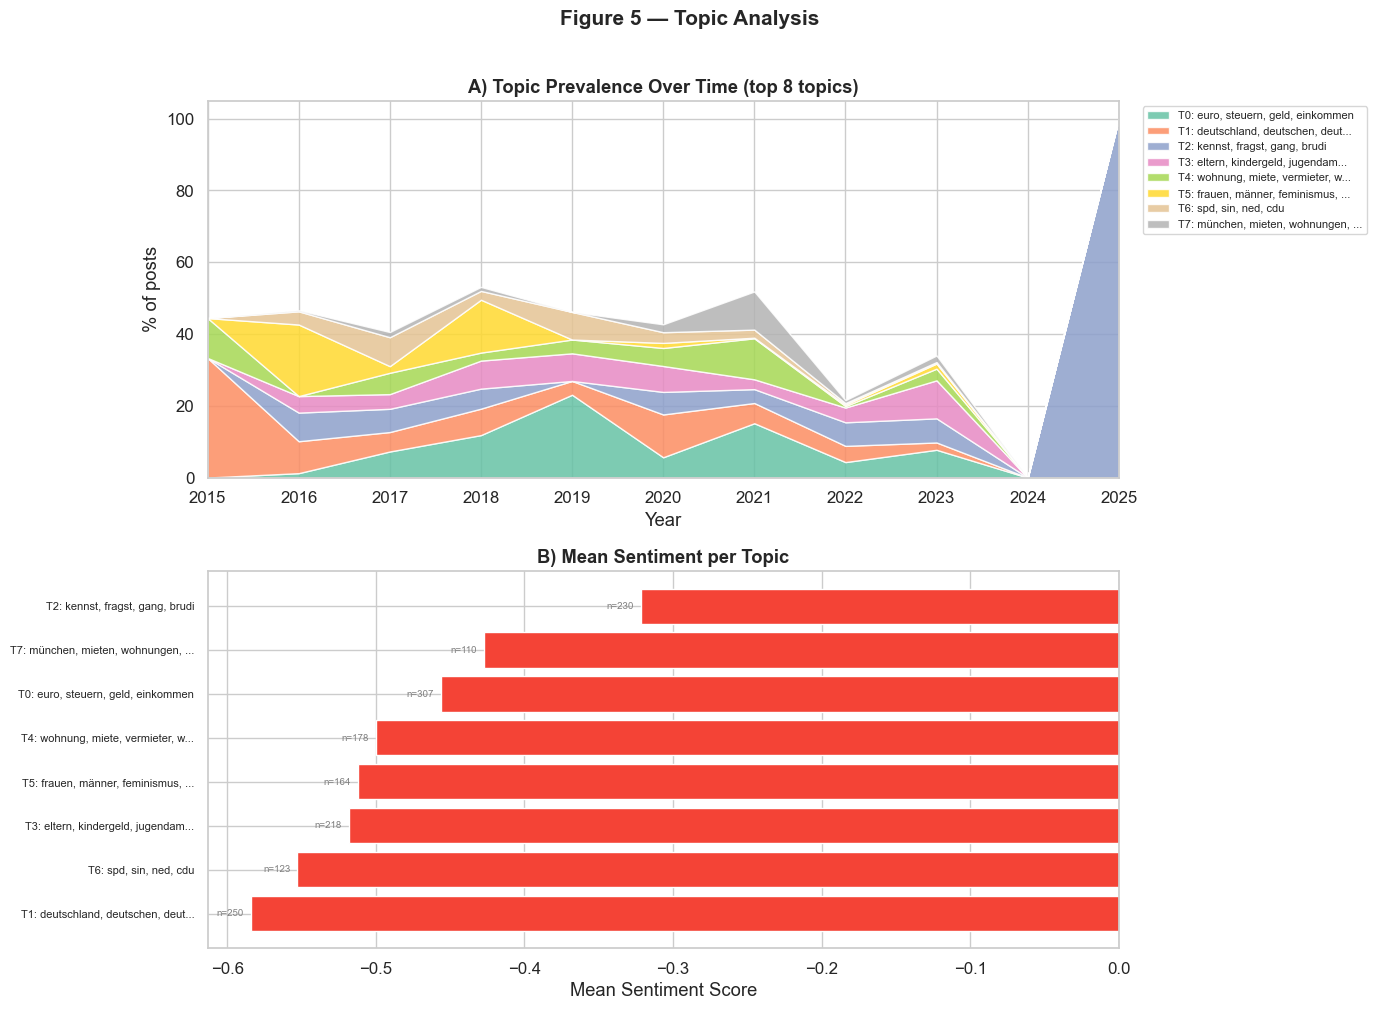

💾 Saved figure5_topics.png


In [13]:
# Cell 8d — Figure 5: Topic evolution over time

if len(df) > 0 and "topic_id" in df.columns:
    # Use only classified posts (not outliers)
    real = df[df["topic_id"] != -1].copy()

    # Get top 8 topics by count
    top_tids = real["topic_id"].value_counts().head(8).index.tolist()
    top_labels = {
        tid: real[real["topic_id"] == tid]["topic_label"].iloc[0]
        for tid in top_tids
    }

    # Build year × topic prevalence matrix (% of posts per year)
    years = sorted(real["year"].dropna().unique())
    prevalence = pd.DataFrame(index=years, columns=top_tids, dtype=float)
    for year in years:
        yr_df = real[real["year"] == year]
        yr_n = len(yr_df)
        for tid in top_tids:
            prevalence.loc[year, tid] = (
                (yr_df["topic_id"] == tid).sum() / max(yr_n, 1) * 100
            )

    # ── Figure 5A: Stacked area chart ──
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    ax = axes[0]
    # Use shortened labels
    short_labels = []
    for tid in top_tids:
        lbl = top_labels[tid]
        if len(lbl) > 35:
            lbl = lbl[:32] + "..."
        short_labels.append(lbl)

    colors = plt.cm.Set2(np.linspace(0, 1, len(top_tids)))
    ax.stackplot(
        years,
        [prevalence[tid].values for tid in top_tids],
        labels=short_labels,
        colors=colors,
        alpha=0.85,
    )
    ax.set_title("A) Topic Prevalence Over Time (top 8 topics)", weight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("% of posts")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
    ax.set_xticks(years)
    ax.set_xlim(min(years), max(years))

    # ── Figure 5B: Topic × sentiment heatmap ──
    ax = axes[1]
    topic_sent = (
        real.groupby("topic_id")["sentiment_score"]
        .mean()
        .reindex(top_tids)
    )
    topic_counts = real["topic_id"].value_counts().reindex(top_tids)

    # Build a DataFrame for a horizontal bar chart
    bar_data = pd.DataFrame({
        "label": short_labels,
        "mean_sentiment": topic_sent.values,
        "count": topic_counts.values,
    }).sort_values("mean_sentiment")

    bar_colors = [
        "#4CAF50" if v > 0.05 else "#F44336" if v < -0.05 else "#FFC107"
        for v in bar_data["mean_sentiment"]
    ]
    bars = ax.barh(
        range(len(bar_data)), bar_data["mean_sentiment"],
        color=bar_colors, edgecolor="white"
    )
    ax.set_yticks(range(len(bar_data)))
    ax.set_yticklabels(bar_data["label"], fontsize=8)
    ax.set_xlabel("Mean Sentiment Score")
    ax.set_title("B) Mean Sentiment per Topic", weight="bold")
    ax.axvline(0, color="grey", linestyle=":", linewidth=0.8)

    # Add count annotations
    for i, (_, row) in enumerate(bar_data.iterrows()):
        ax.annotate(
            f"n={int(row['count']):,}",
            xy=(row["mean_sentiment"], i),
            xytext=(5 if row["mean_sentiment"] >= 0 else -5, 0),
            textcoords="offset points",
            ha="left" if row["mean_sentiment"] >= 0 else "right",
            va="center", fontsize=7, color="grey",
        )

    plt.suptitle(
        "Figure 5 — Topic Analysis",
        fontsize=15, weight="bold", y=1.01,
    )
    plt.tight_layout()
    fig.savefig("figure5_topics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved figure5_topics.png")
else:
    print("⚠️  No topic data to plot.")

## Cell 8e — Figure 6: Era Comparison & Topic Deep-Dive

A four-panel figure comparing the earlier period (2015–2018) with the
later period (2019–2023): which topics grew, which shrank, and how
the sentiment landscape shifted within each topic.

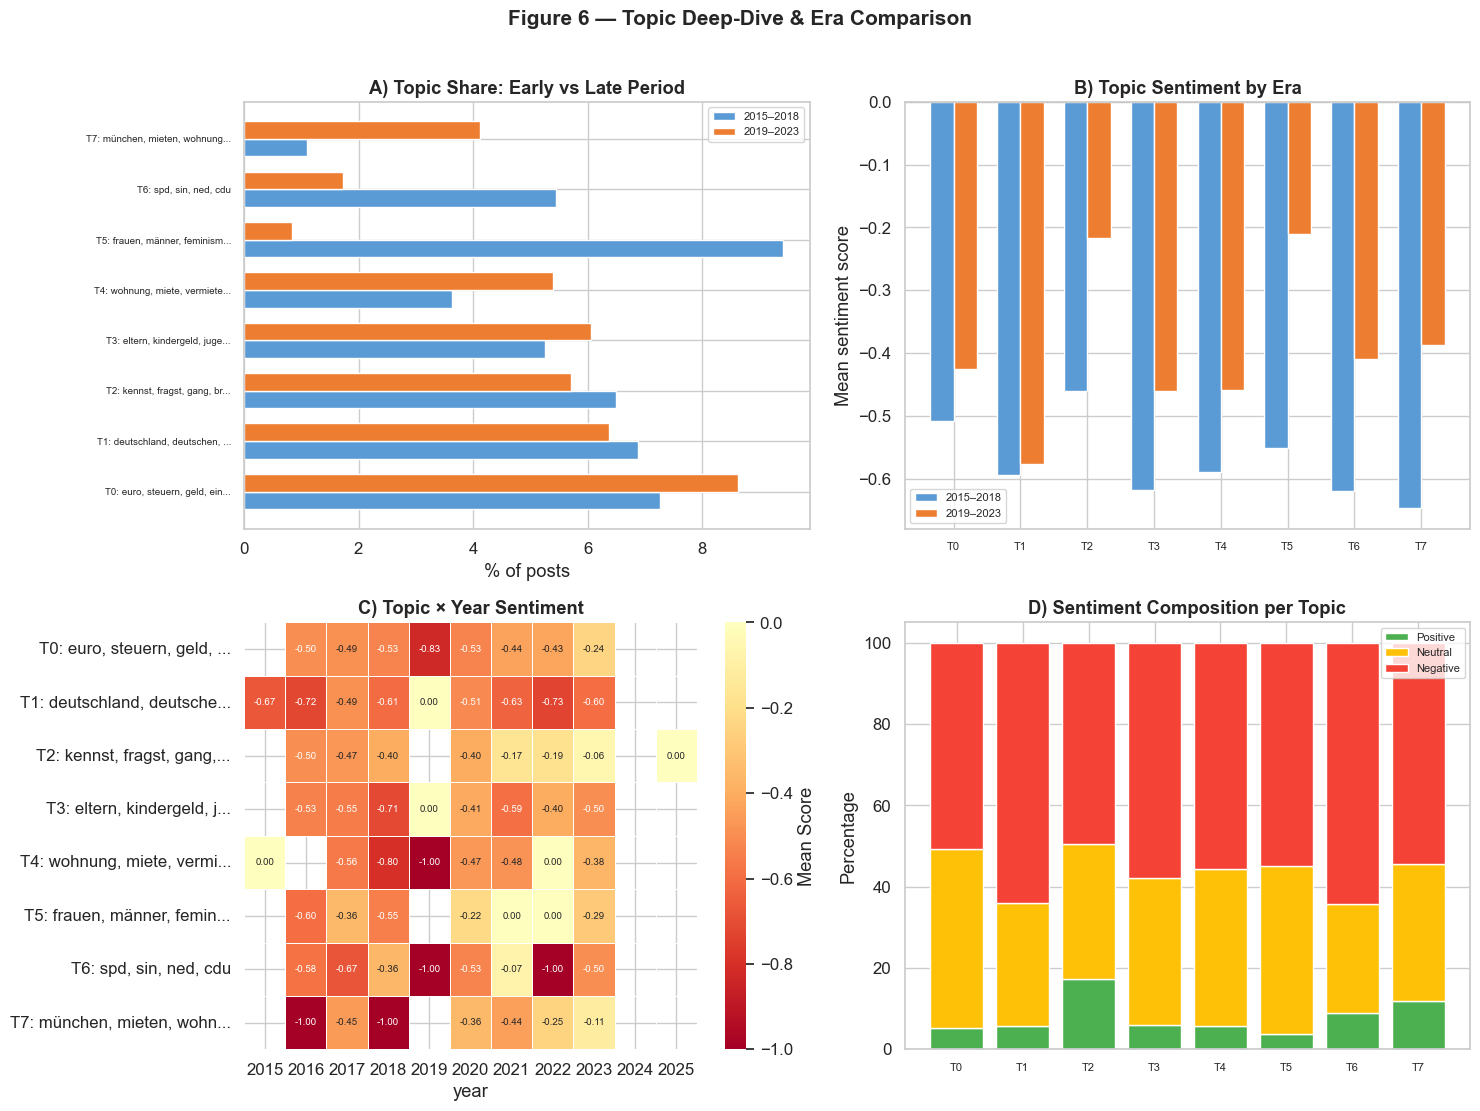

💾 Saved figure6_topic_deepdive.png


In [14]:
# Cell 8e — Figure 6: Era comparison + topic deep-dive

if len(df) > 0 and "topic_id" in df.columns:
    real = df[df["topic_id"] != -1].copy()
    top_tids = real["topic_id"].value_counts().head(8).index.tolist()

    early = real[real["year"].between(2015, 2018)]
    late  = real[real["year"].between(2019, 2023)]

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    # ── A) Topic share shift: early vs late ──
    ax = axes[0, 0]
    if len(early) > 0 and len(late) > 0:
        early_pct = early["topic_id"].value_counts(normalize=True).reindex(top_tids, fill_value=0) * 100
        late_pct  = late["topic_id"].value_counts(normalize=True).reindex(top_tids, fill_value=0) * 100
        short_labels = []
        for tid in top_tids:
            lbl = real[real["topic_id"] == tid]["topic_label"].iloc[0]
            short_labels.append(lbl[:28] + "..." if len(lbl) > 30 else lbl)

        x = np.arange(len(top_tids))
        w = 0.35
        ax.barh(x - w/2, early_pct.values, w, label="2015–2018", color="#5B9BD5")
        ax.barh(x + w/2, late_pct.values, w, label="2019–2023", color="#ED7D31")
        ax.set_yticks(x)
        ax.set_yticklabels(short_labels, fontsize=7)
        ax.set_xlabel("% of posts")
        ax.legend(fontsize=8)
    ax.set_title("A) Topic Share: Early vs Late Period", weight="bold")

    # ── B) Topic sentiment by era (grouped bars) ──
    ax = axes[0, 1]
    if len(early) > 0 and len(late) > 0:
        early_sent = early.groupby("topic_id")["sentiment_score"].mean().reindex(top_tids, fill_value=0)
        late_sent  = late.groupby("topic_id")["sentiment_score"].mean().reindex(top_tids, fill_value=0)

        x = np.arange(len(top_tids))
        w = 0.35
        ax.bar(x - w/2, early_sent.values, w, label="2015–2018", color="#5B9BD5")
        ax.bar(x + w/2, late_sent.values, w, label="2019–2023", color="#ED7D31")
        ax.set_xticks(x)
        ax.set_xticklabels([f"T{t}" for t in top_tids], fontsize=8)
        ax.set_ylabel("Mean sentiment score")
        ax.axhline(0, color="grey", linestyle=":", linewidth=0.8)
        ax.legend(fontsize=8)
    ax.set_title("B) Topic Sentiment by Era", weight="bold")

    # ── C) Heatmap: topic × year mean sentiment ──
    ax = axes[1, 0]
    heat_data = real.pivot_table(
        index="topic_id", columns="year",
        values="sentiment_score", aggfunc="mean"
    )
    # Keep only top topics
    heat_data = heat_data.reindex(top_tids)
    # Replace topic IDs with short labels
    row_labels = [
        (real[real["topic_id"] == tid]["topic_label"].iloc[0][:25] + "..."
         if len(real[real["topic_id"] == tid]["topic_label"].iloc[0]) > 27
         else real[real["topic_id"] == tid]["topic_label"].iloc[0])
        for tid in top_tids
    ]
    heat_data.index = row_labels

    sns.heatmap(
        heat_data, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
        ax=ax, cbar_kws={"label": "Mean Score"}, linewidths=0.5,
        annot_kws={"fontsize": 7},
    )
    ax.set_title("C) Topic × Year Sentiment", weight="bold")
    ax.set_ylabel("")

    # ── D) Stacked sentiment within each top topic ──
    ax = axes[1, 1]
    topic_sent_dist = []
    for tid in top_tids:
        sub = real[real["topic_id"] == tid]
        n_sub = len(sub)
        if n_sub == 0:
            topic_sent_dist.append({"tid": tid, "pos": 0, "neu": 0, "neg": 0})
            continue
        topic_sent_dist.append({
            "tid": tid,
            "pos": (sub["primary_sentiment"] == "positive").sum() / n_sub * 100,
            "neu": (sub["primary_sentiment"] == "neutral").sum() / n_sub * 100,
            "neg": (sub["primary_sentiment"] == "negative").sum() / n_sub * 100,
        })
    tsd = pd.DataFrame(topic_sent_dist)
    x = np.arange(len(top_tids))
    ax.bar(x, tsd["pos"], label="Positive", color="#4CAF50", edgecolor="white")
    ax.bar(x, tsd["neu"], bottom=tsd["pos"], label="Neutral", color="#FFC107", edgecolor="white")
    ax.bar(x, tsd["neg"], bottom=tsd["pos"] + tsd["neu"], label="Negative",
           color="#F44336", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([f"T{t}" for t in top_tids], fontsize=8)
    ax.set_ylabel("Percentage")
    ax.set_title("D) Sentiment Composition per Topic", weight="bold")
    ax.legend(fontsize=8)

    plt.suptitle(
        "Figure 6 — Topic Deep-Dive & Era Comparison",
        fontsize=15, weight="bold", y=1.01,
    )
    plt.tight_layout()
    fig.savefig("figure6_topic_deepdive.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved figure6_topic_deepdive.png")
else:
    print("⚠️  No topic data to plot.")

## Cell 9 — Statistical Tests

Five non-parametric and correlation tests to assess whether sentiment  
has changed significantly over time and across communities.

In [15]:
# Cell 9 — Statistical tests with plain-English interpretation

stat_results = {}

if len(df) > 0 and "sentiment_score" in df.columns:
    yearly_mean = df.groupby("year")["sentiment_score"].mean()
    years_sorted = sorted(yearly_mean.index)
    means_sorted = [yearly_mean[y] for y in years_sorted]

    print("=" * 72)
    print("STATISTICAL ANALYSIS")
    print("=" * 72)

    # 1. Mann-Kendall (Kendall's tau) trend test
    tau, p_mk = stats.kendalltau(range(len(means_sorted)), means_sorted)
    direction = "positive" if tau > 0 else "negative" if tau < 0 else "no"
    sig = "Significant" if p_mk < 0.05 else "Not significant"
    stat_results["mann_kendall"] = {"tau": round(tau, 4), "p_value": round(p_mk, 4)}
    print(f"\n1. Mann-Kendall Trend Test (Kendall τ)")
    print(f"   τ = {tau:.4f},  p = {p_mk:.4f}")
    print(f"   → {sig} {direction} trend in yearly mean sentiment.")

    # 2. Kruskal-Wallis across all years
    year_groups = [g["sentiment_score"].values for _, g in df.groupby("year") if len(g) > 0]
    if len(year_groups) >= 2:
        h_stat, p_kw = stats.kruskal(*year_groups)
    else:
        h_stat, p_kw = 0, 1.0
    sig = "Significant" if p_kw < 0.05 else "Not significant"
    stat_results["kruskal_wallis"] = {"H": round(h_stat, 4), "p_value": round(p_kw, 4)}
    print(f"\n2. Kruskal-Wallis Test (across all years)")
    print(f"   H = {h_stat:.4f},  p = {p_kw:.4f}")
    print(f"   → {sig} difference in sentiment distributions across years.")

    # 3. Mann-Whitney U: 2015-2018 vs 2019-2023
    early = df[df["year"].between(2015, 2018)]["sentiment_score"]
    late = df[df["year"].between(2019, 2023)]["sentiment_score"]
    if len(early) > 0 and len(late) > 0:
        u_stat, p_mw = stats.mannwhitneyu(early, late, alternative="two-sided")
    else:
        u_stat, p_mw = 0, 1.0
    sig = "Significant" if p_mw < 0.05 else "Not significant"
    stat_results["mann_whitney"] = {"U": round(u_stat, 4), "p_value": round(p_mw, 4)}
    diff_dir = "more positive" if late.mean() > early.mean() else "more negative"
    print(f"\n3. Mann-Whitney U Test (2015–2018 vs 2019–2023)")
    print(f"   U = {u_stat:.4f},  p = {p_mw:.4f}")
    print(f"   → {sig} shift; the later period is {diff_dir} on average.")

    # 4. Chi-square: sentiment distribution × subreddit
    ct = pd.crosstab(df["subreddit"], df["primary_sentiment"])
    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
        chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
    else:
        chi2, p_chi, dof = 0, 1.0, 0
    sig = "Significant" if p_chi < 0.05 else "Not significant"
    stat_results["chi_square"] = {"chi2": round(chi2, 4), "p_value": round(p_chi, 4), "dof": dof}
    print(f"\n4. Chi-Square Test (sentiment × subreddit)")
    print(f"   χ² = {chi2:.4f},  p = {p_chi:.4f},  dof = {dof}")
    print(f"   → {sig} association between subreddit and sentiment distribution.")

    # 5. Pearson correlation: post volume vs % negative per year
    yr_vol = df.groupby("year").size()
    yr_neg = df.groupby("year").apply(lambda x: (x["primary_sentiment"] == "negative").mean())
    common_yrs = sorted(set(yr_vol.index) & set(yr_neg.index))
    if len(common_yrs) >= 3:
        r_val, p_corr = stats.pearsonr(
            [yr_vol[y] for y in common_yrs],
            [yr_neg[y] for y in common_yrs]
        )
    else:
        r_val, p_corr = 0, 1.0
    sig = "Significant" if p_corr < 0.05 else "Not significant"
    stat_results["pearson_vol_neg"] = {"r": round(r_val, 4), "p_value": round(p_corr, 4)}
    direction = "positive" if r_val > 0 else "negative"
    print(f"\n5. Pearson Correlation (post volume vs % negative)")
    print(f"   r = {r_val:.4f},  p = {p_corr:.4f}")
    print(f"   → {sig} {direction} correlation between post volume and negativity.")

    print("\n" + "=" * 72)
else:
    print("⚠️  Insufficient data for statistical tests.")

STATISTICAL ANALYSIS

1. Mann-Kendall Trend Test (Kendall τ)
   τ = 0.5505,  p = 0.0191
   → Significant positive trend in yearly mean sentiment.

2. Kruskal-Wallis Test (across all years)
   H = 34.0697,  p = 0.0002
   → Significant difference in sentiment distributions across years.

3. Mann-Whitney U Test (2015–2018 vs 2019–2023)
   U = 4056685.5000,  p = 0.0000
   → Significant shift; the later period is more positive on average.

4. Chi-Square Test (sentiment × subreddit)
   χ² = 41.7349,  p = 0.0000,  dof = 6
   → Significant association between subreddit and sentiment distribution.

5. Pearson Correlation (post volume vs % negative)
   r = 0.6773,  p = 0.0220
   → Significant positive correlation between post volume and negativity.



## Cell 10 — Figure 1: Post Volume per Year by Subreddit

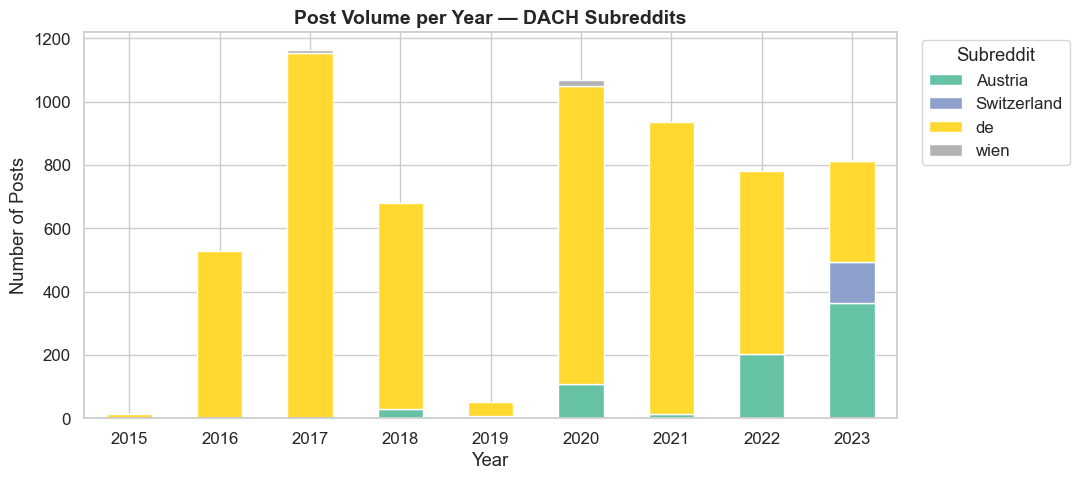

💾 Saved figure1_volume.png


In [16]:
# Cell 10 — Figure 1: Stacked bar chart of post volume

if len(df) > 0:
    pivot = df.pivot_table(index="year", columns="subreddit",
                           values="id", aggfunc="count", fill_value=0)
    pivot = pivot.reindex(YEARS, fill_value=0)

    fig, ax = plt.subplots(figsize=(11, 5))
    pivot.plot(kind="bar", stacked=True, ax=ax, colormap="Set2", edgecolor="white")
    ax.set_title("Post Volume per Year — DACH Subreddits", fontsize=14, weight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of Posts")
    ax.set_xticklabels([str(y) for y in YEARS], rotation=0)
    ax.legend(title="Subreddit", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    fig.savefig("figure1_volume.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved figure1_volume.png")
else:
    print("⚠️  No data to plot.")

## Cell 11 — Figure 2: Four-Panel Sentiment Overview

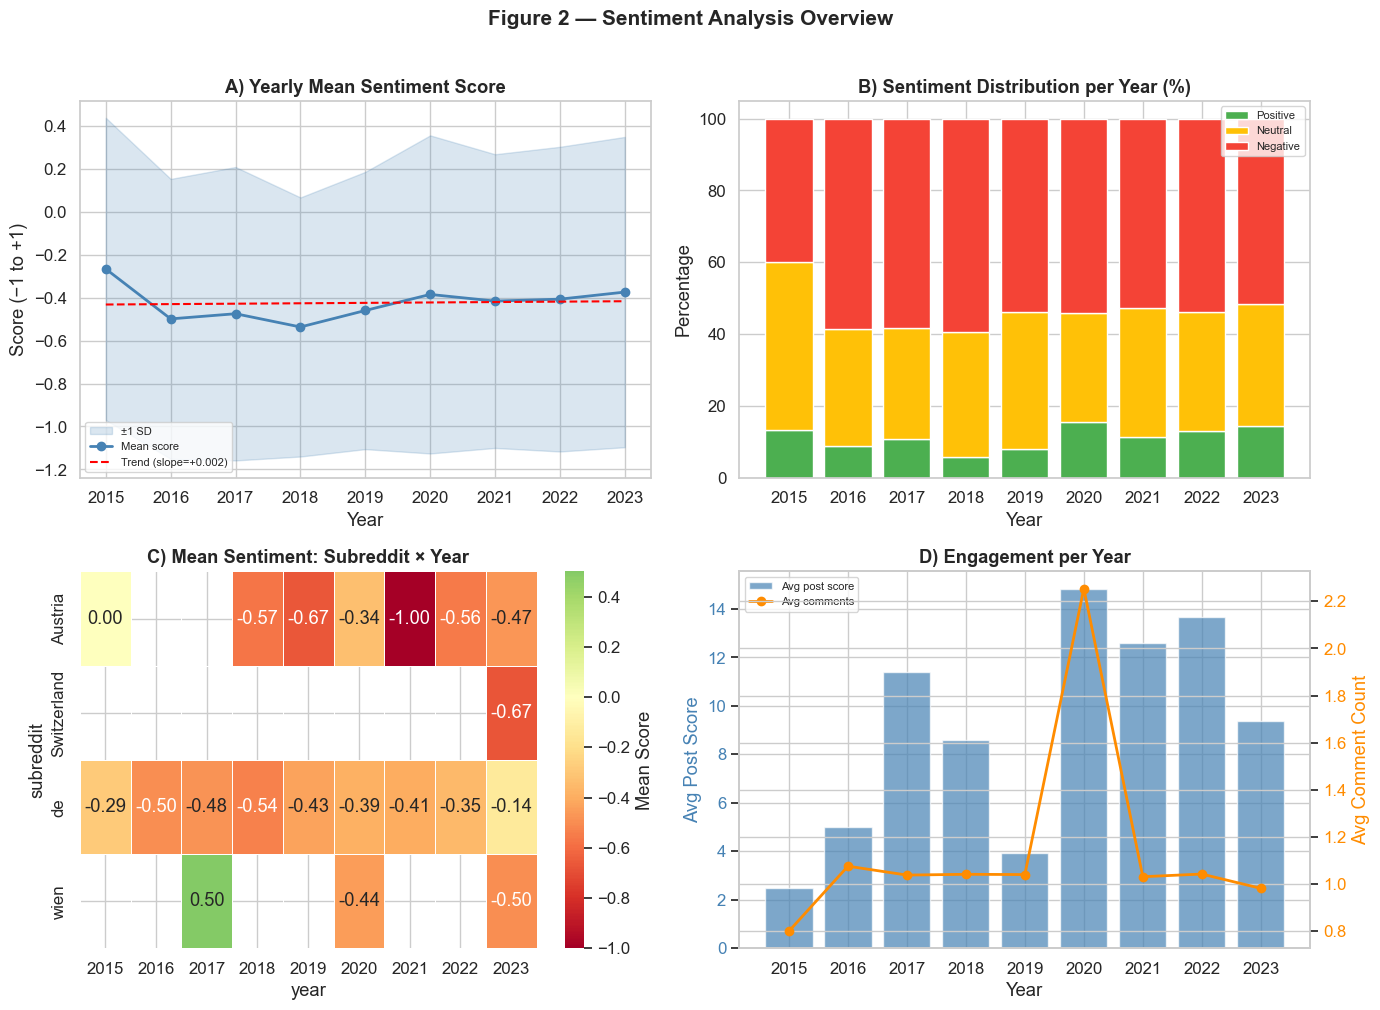

💾 Saved figure2_sentiment.png


In [17]:
# Cell 11 — Figure 2: Four-panel sentiment overview

if len(df) > 0 and "sentiment_score" in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ── A) Mean sentiment per year with trend line and SD band ──
    ax = axes[0, 0]
    ym = df.groupby("year")["sentiment_score"].agg(["mean", "std"]).reindex(YEARS)
    ax.fill_between(ym.index, ym["mean"] - ym["std"], ym["mean"] + ym["std"],
                    alpha=0.2, color="steelblue", label="±1 SD")
    ax.plot(ym.index, ym["mean"], "o-", color="steelblue", linewidth=2, label="Mean score")
    # Linear trend
    valid = ym["mean"].dropna()
    if len(valid) >= 2:
        z = np.polyfit(valid.index, valid.values, 1)
        ax.plot(valid.index, np.polyval(z, valid.index), "--", color="red",
                linewidth=1.5, label=f"Trend (slope={z[0]:+.3f})")
    ax.set_title("A) Yearly Mean Sentiment Score", weight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Score (−1 to +1)")
    ax.legend(fontsize=8); ax.set_xticks(YEARS)

    # ── B) Stacked % bar chart ──
    ax = axes[0, 1]
    yr_sent = df.groupby(["year", "primary_sentiment"]).size().unstack(fill_value=0)
    yr_pct = yr_sent.div(yr_sent.sum(axis=1), axis=0) * 100
    yr_pct = yr_pct.reindex(YEARS, fill_value=0)
    colors = {"positive": "#4CAF50", "neutral": "#FFC107", "negative": "#F44336"}
    bottom = np.zeros(len(YEARS))
    for label in ["positive", "neutral", "negative"]:
        vals = yr_pct[label].values if label in yr_pct.columns else np.zeros(len(YEARS))
        ax.bar(YEARS, vals, bottom=bottom, label=label.capitalize(),
               color=colors[label], edgecolor="white")
        bottom += vals
    ax.set_title("B) Sentiment Distribution per Year (%)", weight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Percentage")
    ax.legend(fontsize=8); ax.set_xticks(YEARS)

    # ── C) Heatmap: subreddit × year ──
    ax = axes[1, 0]
    heat = df.pivot_table(index="subreddit", columns="year",
                          values="sentiment_score", aggfunc="mean")
    heat = heat.reindex(columns=YEARS)
    sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                ax=ax, cbar_kws={"label": "Mean Score"}, linewidths=0.5)
    ax.set_title("C) Mean Sentiment: Subreddit × Year", weight="bold")

    # ── D) Dual-axis: avg score (bars) + avg comments (line) ──
    ax = axes[1, 1]
    yr_stats = df.groupby("year").agg(
        avg_score=("score", "mean"),
        avg_comments=("num_comments", "mean")
    ).reindex(YEARS)
    ax.bar(YEARS, yr_stats["avg_score"], color="steelblue", alpha=0.7, label="Avg post score")
    ax.set_xlabel("Year"); ax.set_ylabel("Avg Post Score", color="steelblue")
    ax.tick_params(axis="y", labelcolor="steelblue")
    ax.set_xticks(YEARS)

    ax2 = ax.twinx()
    ax2.plot(YEARS, yr_stats["avg_comments"], "o-", color="darkorange",
             linewidth=2, label="Avg comments")
    ax2.set_ylabel("Avg Comment Count", color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")
    ax.set_title("D) Engagement per Year", weight="bold")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")

    plt.suptitle("Figure 2 — Sentiment Analysis Overview", fontsize=15, weight="bold", y=1.01)
    plt.tight_layout()
    fig.savefig("figure2_sentiment.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved figure2_sentiment.png")
else:
    print("⚠️  No sentiment data to plot.")

## Cell 12 — Figure 3: Language & Keyword Trends

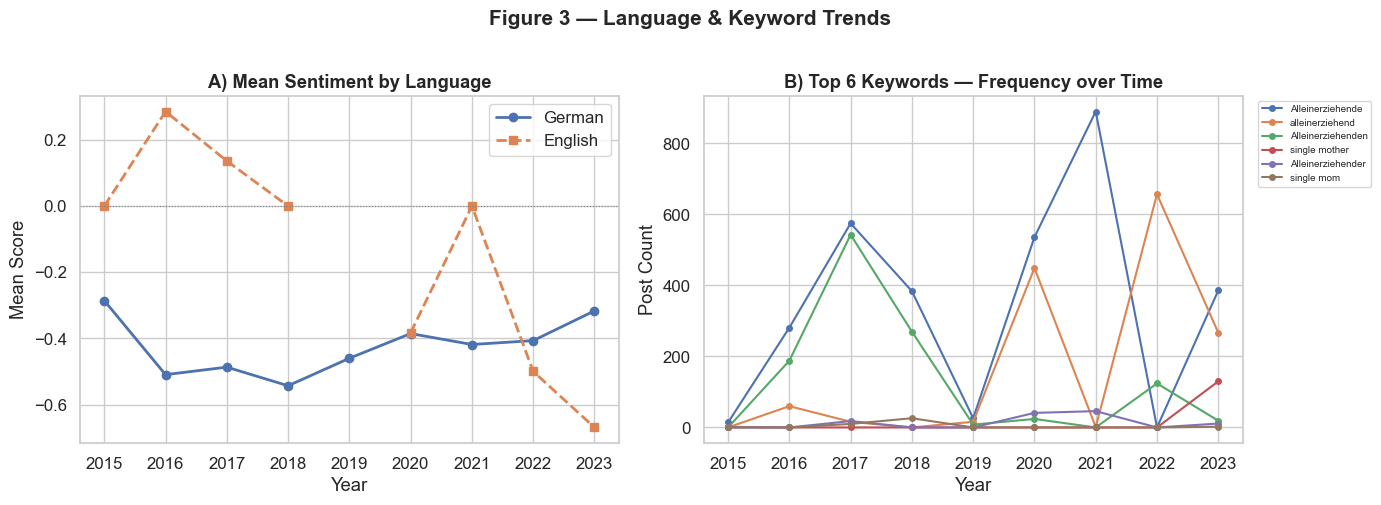

💾 Saved figure3_language_keywords.png


In [18]:
# Cell 12 — Figure 3: Language split + keyword frequency over time

if len(df) > 0 and "sentiment_score" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── A) Sentiment by language per year ──
    ax = axes[0]
    for lang, style in [("de", "o-"), ("en", "s--")]:
        sub = df[df["language"] == lang]
        ym = sub.groupby("year")["sentiment_score"].mean().reindex(YEARS)
        label = "German" if lang == "de" else "English"
        ax.plot(ym.index, ym.values, style, label=label, linewidth=2, markersize=6)
    ax.axhline(0, color="grey", linestyle=":", linewidth=0.8)
    ax.set_title("A) Mean Sentiment by Language", weight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Mean Score")
    ax.legend(); ax.set_xticks(YEARS)

    # ── B) Top 6 keywords frequency over time ──
    ax = axes[1]
    kw_yr = df.groupby(["_query_keyword", "year"]).size().unstack(fill_value=0)
    top6 = kw_yr.sum(axis=1).nlargest(6).index
    for kw in top6:
        vals = kw_yr.loc[kw].reindex(YEARS, fill_value=0)
        ax.plot(vals.index, vals.values, "o-", label=kw[:25], linewidth=1.5, markersize=4)
    ax.set_title("B) Top 6 Keywords — Frequency over Time", weight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Post Count")
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_xticks(YEARS)

    plt.suptitle("Figure 3 — Language & Keyword Trends", fontsize=15, weight="bold", y=1.01)
    plt.tight_layout()
    fig.savefig("figure3_language_keywords.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved figure3_language_keywords.png")
else:
    print("⚠️  No data to plot.")

## Cell 13 — Figure 4: Opinion Distribution Summary

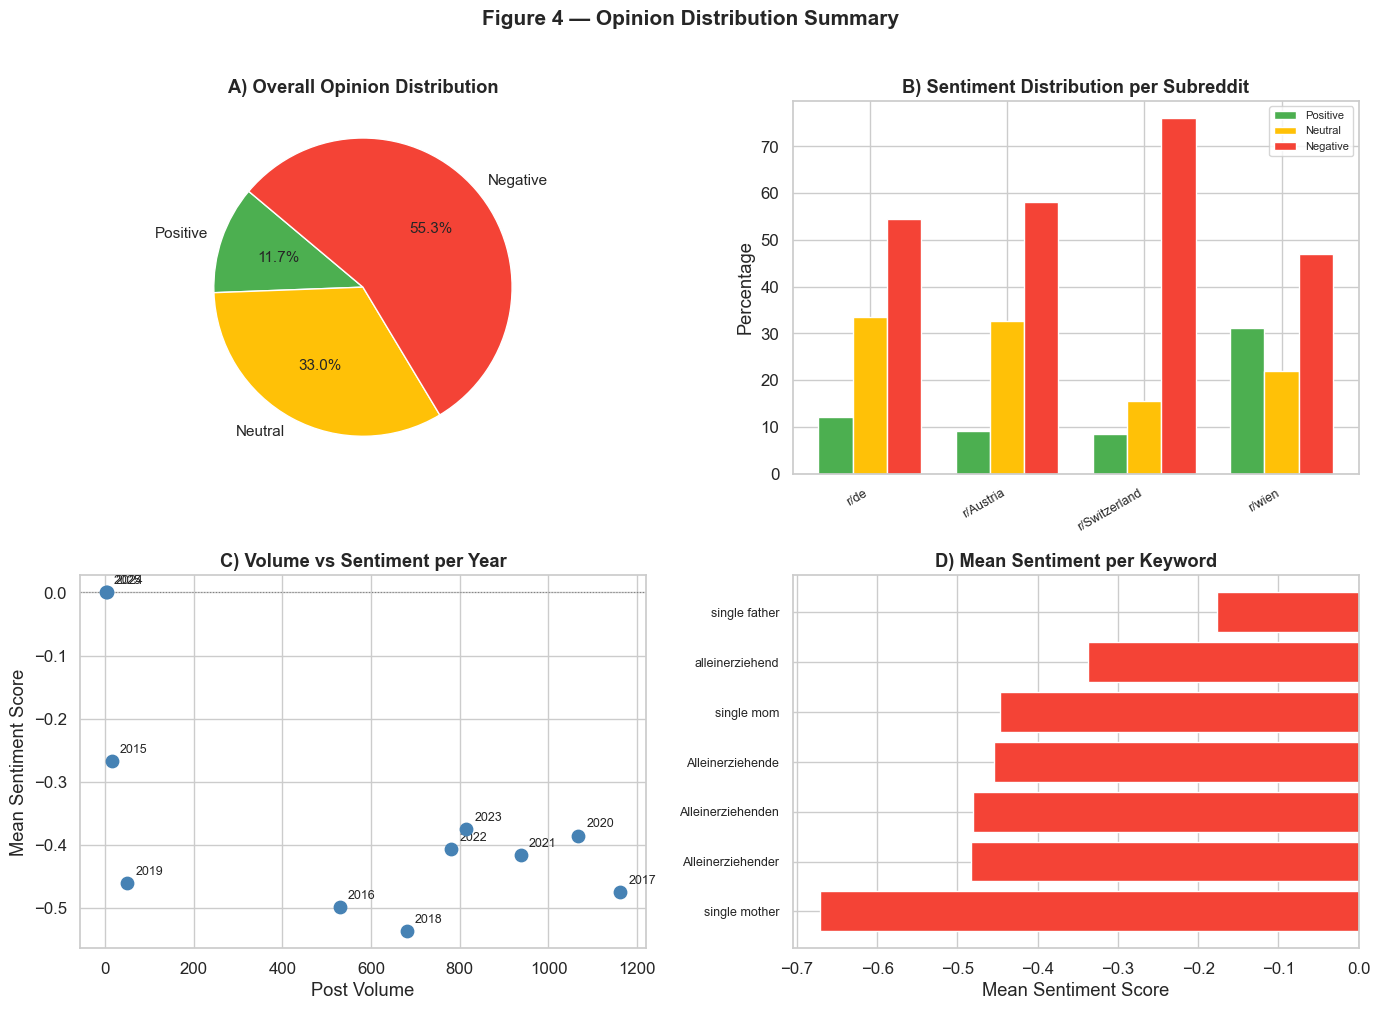

💾 Saved figure4_opinion.png


In [19]:
# Cell 13 — Figure 4: Four-panel opinion distribution summary

if len(df) > 0 and "primary_sentiment" in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors_list = ["#4CAF50", "#FFC107", "#F44336"]
    labels_order = ["positive", "neutral", "negative"]

    # ── A) Pie chart: overall split ──
    ax = axes[0, 0]
    counts = [int((df["primary_sentiment"] == l).sum()) for l in labels_order]
    ax.pie(counts, labels=[l.capitalize() for l in labels_order],
           colors=colors_list, autopct="%1.1f%%", startangle=140,
           textprops={"fontsize": 11})
    ax.set_title("A) Overall Opinion Distribution", weight="bold")

    # ── B) Grouped bar: sentiment per subreddit ──
    ax = axes[0, 1]
    subs = df["subreddit"].value_counts().index.tolist()
    x = np.arange(len(subs))
    width = 0.25
    for i, label in enumerate(labels_order):
        vals = [(df[(df["subreddit"] == s) & (df["primary_sentiment"] == label)].shape[0]
                 / max(df[df["subreddit"] == s].shape[0], 1)) * 100 for s in subs]
        ax.bar(x + i * width, vals, width, label=label.capitalize(), color=colors_list[i])
    ax.set_xticks(x + width)
    ax.set_xticklabels([f"r/{s}" for s in subs], rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Percentage")
    ax.set_title("B) Sentiment Distribution per Subreddit", weight="bold")
    ax.legend(fontsize=8)

    # ── C) Scatter: post volume vs mean sentiment per year ──
    ax = axes[1, 0]
    yr_agg = df.groupby("year").agg(
        volume=("id", "count"),
        mean_sent=("sentiment_score", "mean")
    )
    ax.scatter(yr_agg["volume"], yr_agg["mean_sent"], s=80, c="steelblue", zorder=5)
    for yr, row in yr_agg.iterrows():
        ax.annotate(str(int(yr)), (row["volume"], row["mean_sent"]),
                    textcoords="offset points", xytext=(6, 6), fontsize=9)
    ax.set_xlabel("Post Volume")
    ax.set_ylabel("Mean Sentiment Score")
    ax.set_title("C) Volume vs Sentiment per Year", weight="bold")
    ax.axhline(0, color="grey", linestyle=":", linewidth=0.8)

    # ── D) Bar: mean sentiment per keyword ──
    ax = axes[1, 1]
    kw_sent = df.groupby("_query_keyword")["sentiment_score"].mean().sort_values(ascending=False)
    bar_colors = ["#4CAF50" if v > 0.05 else "#F44336" if v < -0.05 else "#FFC107"
                  for v in kw_sent.values]
    ax.barh(range(len(kw_sent)), kw_sent.values, color=bar_colors)
    ax.set_yticks(range(len(kw_sent)))
    ax.set_yticklabels(kw_sent.index, fontsize=9)
    ax.set_xlabel("Mean Sentiment Score")
    ax.set_title("D) Mean Sentiment per Keyword", weight="bold")
    ax.axvline(0, color="grey", linestyle=":", linewidth=0.8)
    ax.invert_yaxis()

    plt.suptitle("Figure 4 — Opinion Distribution Summary",
                 fontsize=15, weight="bold", y=1.01)
    plt.tight_layout()
    fig.savefig("figure4_opinion.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved figure4_opinion.png")
else:
    print("⚠️  No data to plot.")

## Cell 14 — Export All Outputs

Save the full annotated dataset, yearly aggregates, and analysis metadata.

In [20]:
# Cell 14 — Export CSV, JSON, and summary files

if len(df) > 0:
    # ── Full dataset CSV ──
    export_cols = [
        "id", "type", "parent_post_id", "subreddit", "author", "title",
        "full_text", "score", "num_comments", "created_utc", "date", "year",
        "language", "_query_keyword", "vader_sentiment", "roberta_sentiment",
        "roberta_confidence", "primary_sentiment", "sentiment_score",
        "topic_id", "topic_label",
    ]
    existing_cols = [c for c in export_cols if c in df.columns]
    df[existing_cols].to_csv("reddit_dach_singleparent_full.csv", index=False)
    print("💾 reddit_dach_singleparent_full.csv")

    # ── Comments-only CSV ──
    comments_df = df[df["type"] == "comment"]
    comments_df[existing_cols].to_csv("reddit_dach_singleparent_comments.csv", index=False)
    print(f"💾 reddit_dach_singleparent_comments.csv  ({len(comments_df):,} comments)")

    # ── Yearly aggregates CSV ──
    yearly_agg = df.groupby("year").agg(
        total_posts=("id", "count"),
        mean_score=("score", "mean"),
        mean_comments=("num_comments", "mean"),
        mean_sentiment=("sentiment_score", "mean"),
        pct_positive=("primary_sentiment", lambda x: (x == "positive").mean() * 100),
        pct_neutral=("primary_sentiment", lambda x: (x == "neutral").mean() * 100),
        pct_negative=("primary_sentiment", lambda x: (x == "negative").mean() * 100),
        pct_german=("language", lambda x: (x == "de").mean() * 100),
    ).round(3)
    yearly_agg.to_csv("yearly_aggregates.csv")
    print("💾 yearly_aggregates.csv")

    # ── Analysis summary JSON ──
    summary = {
        "metadata": {
            "generated": datetime.now().isoformat(),
            "subreddits": SUBREDDITS,
            "keywords": KEYWORDS,
            "year_range": [YEAR_START, YEAR_END],
            "total_records": len(df),
            "total_posts": int((df["type"] == "post").sum()),
            "total_comments": int((df["type"] == "comment").sum()),
        },
        "preprocessing": PREPROCESS_STATS,
        "statistical_tests": stat_results if "stat_results" in dir() else {},
        "overall_sentiment": {
            "positive": int((df["primary_sentiment"] == "positive").sum()),
            "neutral": int((df["primary_sentiment"] == "neutral").sum()),
            "negative": int((df["primary_sentiment"] == "negative").sum()),
            "mean_score": round(df["sentiment_score"].mean(), 4),
        },
    }
    # Add topic info if available
    if "topic_id" in df.columns:
        summary["topics"] = {
            "n_topics": int(df[df["topic_id"] != -1]["topic_id"].nunique()),
            "n_outliers": int((df["topic_id"] == -1).sum()),
            "topic_distribution": df["topic_id"].value_counts().to_dict(),
        }

    with open("analysis_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2, ensure_ascii=False, default=str)
    print("💾 analysis_summary.json")

    # Confirm text reports exist
    for fname in ["dataset_report.txt", "opinion_summary.txt", "topic_report.txt"]:
        status = "✅" if os.path.exists(fname) else "⚠️  missing"
        print(f"{status} {fname}")

    # List all figure files
    for fname in ["figure1_volume.png", "figure2_sentiment.png",
                  "figure3_language_keywords.png", "figure4_opinion.png",
                  "figure5_topics.png", "figure6_topic_deepdive.png"]:
        status = "✅" if os.path.exists(fname) else "⚠️  missing"
        print(f"{status} {fname}")

    print("\n🎉 All outputs exported. Analysis complete!")
else:
    print("⚠️  No data to export.")

💾 reddit_dach_singleparent_full.csv
💾 reddit_dach_singleparent_comments.csv  (5,926 comments)
💾 yearly_aggregates.csv
💾 analysis_summary.json
✅ dataset_report.txt
✅ opinion_summary.txt
✅ topic_report.txt
✅ figure1_volume.png
✅ figure2_sentiment.png
✅ figure3_language_keywords.png
✅ figure4_opinion.png
✅ figure5_topics.png
✅ figure6_topic_deepdive.png

🎉 All outputs exported. Analysis complete!
